In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# 0 - Imports

In [18]:
os.system(
    "pip install -q llama-cpp-python "
    "--extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu124"
)
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
os.system("pip install -q -U timm")

0

In [19]:
# ── Core ──────────────────────────────────────────────────────────
import os
import sys
import json
import random
import warnings
from pathlib import Path
from collections import Counter, defaultdict

# ── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd

import wandb
from kaggle_secrets import UserSecretsClient

# ── Imaging ───────────────────────────────────────────────────────
import pydicom
from pydicom.errors import InvalidDicomError

# ── DL ────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import cv2

# ── Utilities ─────────────────────────────────────────────────────
from tqdm.auto import tqdm
from sklearn.metrics import brier_score_loss, precision_recall_fscore_support, roc_auc_score
from huggingface_hub import hf_hub_download
from llama_cpp import Llama

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
os.system("pip install -q -U transformers accelerate bitsandbytes")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"torch: {torch.__version__} | cuda available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"device: {torch.cuda.get_device_name(0)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 29.9 MB/s eta 0:00:00
torch: 2.10.0+cu128 | cuda available: True
device: Tesla T4
Using device: cuda


In [20]:
# The competition explicitly warns transfer syntax varies: uncompressed
# Explicit VR LE, JPEG Lossless, JPEG 2000, Implicit VR LE. pydicom needs
# plugin decoders for the compressed ones or pixel_array silently fails.
try:
    import pylibjpeg
    print("pylibjpeg: available")
except ImportError:
    print("pylibjpeg: MISSING — run: pip install pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg")

try:
    import gdcm
    print("gdcm: available")
except ImportError:
    print("gdcm: MISSING (fallback decoder) — run: pip install python-gdcm")

pylibjpeg: MISSING — run: pip install pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg
gdcm: MISSING (fallback decoder) — run: pip install python-gdcm


In [21]:
!pip install pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg python-gdcm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 39.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 105.7 MB/s eta 0:00:0000:010:01


In [22]:
class CFG:
    ROOT=Path("/kaggle/input/competitions/rsna-knee-abnormality-detection")

    TRAIN_CSV=ROOT / "train.csv"
    TRAIN_SERIES_CSV=ROOT / "train_series.csv"
    TEST_CSV=ROOT / "test.csv"
    TEST_SERIES_CSV=ROOT / "test_series.csv"
    SAMPLE_SUB_CSV=ROOT / "sample_submission.csv"

    TRAIN_SERIES_DIR=ROOT / "train_series"
    TEST_SERIES_DIR=ROOT / "test_series"

    LABEL_COLS = [
        "ACL", "MCL", "Medial Meniscus", "Lateral Meniscus",
        "Medial OA", "Lateral OA", "PF OA", "Effusion",
        "Synovitis", "Baker's", "Contusion", "Fracture",
    ]

    CANONICAL_SLOTS = [(p, s) for p in ["Sagittal", "Coronal", "Axial"] for s in [0, 1]]
    SLOT_NAMES = [f"{p}_{'fs' if s else 'std'}" for p, s in CANONICAL_SLOTS]
    K_SLICES = 5                 # sampled slices per slot
    INPUT_SIZE = 224             # DINOv3 input resolution
    TARGET_FOV_MM = 180          # from FOV audit: median ~160mm, covers the bulk with margin
    WEAK_LABEL_BASE_WEIGHT = 0.3 # starting point; sweep in Stage 7
    ROUTING_CACHE = Path("/kaggle/working/series_routing.parquet")
    LABEL_CACHE = Path("/kaggle/working/unified_labels.parquet")

for p in [CFG.TRAIN_CSV, CFG.TRAIN_SERIES_CSV, CFG.TEST_CSV,
          CFG.TEST_SERIES_CSV, CFG.SAMPLE_SUB_CSV,
          CFG.TRAIN_SERIES_DIR, CFG.TEST_SERIES_DIR]:
    print(f"{'✓' if p.exists() else '✗ MISSING':10s} {p}")

✓          /kaggle/input/competitions/rsna-knee-abnormality-detection/train.csv
✓          /kaggle/input/competitions/rsna-knee-abnormality-detection/train_series.csv
✓          /kaggle/input/competitions/rsna-knee-abnormality-detection/test.csv
✓          /kaggle/input/competitions/rsna-knee-abnormality-detection/test_series.csv
✓          /kaggle/input/competitions/rsna-knee-abnormality-detection/sample_submission.csv
✓          /kaggle/input/competitions/rsna-knee-abnormality-detection/train_series
✓          /kaggle/input/competitions/rsna-knee-abnormality-detection/test_series


In [23]:
import wandb
from kaggle_secrets import UserSecretsClient

try:
    user_secrets = UserSecretsClient()
    wandb_key = user_secrets.get_secret("WANDB")
    wandb.login(key=wandb_key)
    print("W&B login: OK")
except Exception as e:
    print(f"W&B login failed — check the secret is attached to this notebook. Error: {e}")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


W&B login: OK


# 1 - Initial Loading and Audit

In [24]:
train_df=pd.read_csv(CFG.TRAIN_CSV)
train_series_df=pd.read_csv(CFG.TRAIN_SERIES_CSV)
test_df=pd.read_csv(CFG.TEST_CSV)
test_series_df=pd.read_csv(CFG.TEST_SERIES_CSV)
sample_sub_df=pd.read_csv(CFG.SAMPLE_SUB_CSV)

for name, df in [("train", train_df), ("train_series", train_series_df),
                  ("test", test_df), ("test_series", test_series_df),
                  ("sample_submission", sample_sub_df)]:
    print(f"\n{'='*60}\n{name}: shape={df.shape}\n{'='*60}")
    print(df.dtypes)
    display(df.head(3))


train: shape=(4407, 14)
StudyInstanceUID     object
Report               object
ACL                 float64
MCL                 float64
Medial Meniscus     float64
Lateral Meniscus    float64
Medial OA           float64
Lateral OA          float64
PF OA               float64
Effusion            float64
Synovitis           float64
Baker's             float64
Contusion           float64
Fracture            float64
dtype: object


,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,Técnica: RMN de la rodilla. Resultados: Rotura...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,[DATE]: * MR Knie Rechts 15ch AA Klinische Inl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.10009278692606631573...,Hallazgos:\nNo hay alteraciones en significati...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



train_series: shape=(24371, 5)
StudyInstanceUID     object
SeriesInstanceUID    object
Fluid_Sensitive       int64
Fat_Suppression       int64
Anatomical_Plane     object
dtype: object


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,1,1,Sagittal
1,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.13821229744997220641...,1,1,Axial
2,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.23084836536722595275...,0,0,Coronal



test: shape=(3, 1)
StudyInstanceUID    object
dtype: object


,StudyInstanceUID
0,1.2.826.0.1.3680043.8.498.10047035057544427318...
1,1.2.826.0.1.3680043.8.498.10062861783145312629...
2,1.2.826.0.1.3680043.8.498.10067514707072572280...



test_series: shape=(15, 5)
StudyInstanceUID     object
SeriesInstanceUID    object
Fluid_Sensitive       int64
Fat_Suppression       int64
Anatomical_Plane     object
dtype: object


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.11580656442259111255...,0,0,Axial
1,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.17811502614030631664...,0,0,Sagittal
2,1.2.826.0.1.3680043.8.498.10047035057544427318...,1.2.826.0.1.3680043.8.498.30565395595045942404...,0,0,Sagittal



sample_submission: shape=(3, 13)
StudyInstanceUID     object
ACL                 float64
MCL                 float64
Medial Meniscus     float64
Lateral Meniscus    float64
Medial OA           float64
Lateral OA          float64
PF OA               float64
Effusion            float64
Synovitis           float64
Baker's             float64
Contusion           float64
Fracture            float64
dtype: object


,StudyInstanceUID,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10047035057544427318...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
1,1.2.826.0.1.3680043.8.498.10062861783145312629...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
2,1.2.826.0.1.3680043.8.498.10067514707072572280...,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5


In [25]:
# We're checking whether `Report` (or PatientSex) exists in the test schema.
# If it doesn't, the report is confirmed training-time-only, as discussed —
# this governs the whole vision/text architecture split.
print("train.csv columns:", list(train_df.columns))
print("test.csv columns: ", list(test_df.columns))

train_only_cols = set(train_df.columns) - set(test_df.columns)
print(f"\nColumns present in train but NOT in test: {train_only_cols}")
assert "Report" in train_only_cols, "Unexpected: Report column found in test schema — re-check architecture assumptions."
print("Confirmed: 'Report' is not present in the test schema.")

train.csv columns: ['StudyInstanceUID', 'Report', 'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']
test.csv columns:  ['StudyInstanceUID']

Columns present in train but NOT in test: {'MCL', 'Fracture', 'Medial OA', 'Lateral Meniscus', 'Report', 'Lateral OA', 'Medial Meniscus', 'ACL', 'PF OA', "Baker's", 'Contusion', 'Effusion', 'Synovitis'}
Confirmed: 'Report' is not present in the test schema.


In [26]:
def audit_folder_alignment(df, series_df, series_dir, split_name):
    csv_study_ids = set(df["StudyInstanceUID"])
    disk_study_ids = set(p.name for p in series_dir.iterdir() if p.is_dir()) if series_dir.exists() else set()

    print(f"\n--- {split_name} ---")
    print(f"Studies in CSV: {len(csv_study_ids)} | Study folders on disk: {len(disk_study_ids)}")
    print(f"In CSV but no folder: {len(csv_study_ids - disk_study_ids)}")
    print(f"On disk but not in CSV: {len(disk_study_ids - csv_study_ids)}")

    # Series-level check for a sample of studies (full scan can be slow on train)
    sample_studies = list(csv_study_ids)[:50]
    missing_series = []
    for sid in sample_studies:
        expected_series = set(series_df.loc[series_df.StudyInstanceUID == sid, "SeriesInstanceUID"])
        study_path = series_dir / sid
        actual_series = set(p.name for p in study_path.iterdir() if p.is_dir()) if study_path.exists() else set()
        if expected_series != actual_series:
            missing_series.append(sid)
    print(f"Series mismatch in sample of {len(sample_studies)} studies: {len(missing_series)}")
    return csv_study_ids, disk_study_ids

train_csv_ids, train_disk_ids = audit_folder_alignment(train_df, train_series_df, CFG.TRAIN_SERIES_DIR, "train")
test_csv_ids, test_disk_ids   = audit_folder_alignment(test_df, test_series_df, CFG.TEST_SERIES_DIR, "test")


--- train ---
Studies in CSV: 4407 | Study folders on disk: 4407
In CSV but no folder: 0
On disk but not in CSV: 0
Series mismatch in sample of 50 studies: 0

--- test ---
Studies in CSV: 3 | Study folders on disk: 3
In CSV but no folder: 0
On disk but not in CSV: 0
Series mismatch in sample of 3 studies: 0


In [27]:
label_present_mask = train_df[CFG.LABEL_COLS].notna().all(axis=1)
n_gold = label_present_mask.sum()
n_total = len(train_df)

print(f"Studies with complete gold labels: {n_gold} / {n_total} ({100*n_gold/n_total:.1f}%)")
print(f"Studies relying on report-derived / no labels: {n_total - n_gold}")

print("\nPer-label prevalence (gold-labeled subset only, NaN-safe):")
prevalence = train_df.loc[label_present_mask, CFG.LABEL_COLS].mean().sort_values(ascending=False)
print((prevalence * 100).round(1).astype(str) + "%")

print("\nReport missingness:")
print(f"Missing reports: {train_df['Report'].isna().sum()} / {n_total}")
print(f"Empty-string reports: {(train_df['Report'].fillna('').str.strip() == '').sum()}")

Studies with complete gold labels: 58 / 4407 (1.3%)
Studies relying on report-derived / no labels: 4349

Per-label prevalence (gold-labeled subset only, NaN-safe):
Effusion            60.3%
Synovitis           46.6%
Medial Meniscus     44.8%
ACL                 41.4%
Lateral Meniscus    39.7%
PF OA               36.2%
Contusion           32.8%
Fracture            31.0%
Medial OA           25.9%
Baker's             20.7%
Lateral OA          19.0%
MCL                 15.5%
dtype: object

Report missingness:
Missing reports: 0 / 4407
Empty-string reports: 0


In [28]:
print("Series per study — distribution:")
series_per_study = train_series_df.groupby("StudyInstanceUID").size()
print(series_per_study.describe())

print("\nAnatomical_Plane distribution:")
print(train_series_df["Anatomical_Plane"].value_counts(dropna=False))

print("\nFluid_Sensitive distribution:")
print(train_series_df["Fluid_Sensitive"].value_counts(dropna=False))

print("\nFat_Suppression distribution:")
print(train_series_df["Fat_Suppression"].value_counts(dropna=False))

print("\nPlane x Fluid_Sensitive x Fat_Suppression combos (top 10):")
print(train_series_df.groupby(["Anatomical_Plane", "Fluid_Sensitive", "Fat_Suppression"]).size()
      .sort_values(ascending=False).head(10))

Series per study — distribution:
count    4407.000000
mean        5.530066
std         1.393826
min         3.000000
25%         5.000000
50%         5.000000
75%         6.000000
max        14.000000
dtype: float64

Anatomical_Plane distribution:
Anatomical_Plane
Sagittal    9864
Coronal     8609
Axial       5898
Name: count, dtype: int64

Fluid_Sensitive distribution:
Fluid_Sensitive
1    14010
0    10361
Name: count, dtype: int64

Fat_Suppression distribution:
Fat_Suppression
1    14010
0    10361
Name: count, dtype: int64

Plane x Fluid_Sensitive x Fat_Suppression combos (top 10):
Anatomical_Plane  Fluid_Sensitive  Fat_Suppression
Sagittal          0                0                  5197
Axial             1                1                  4719
Sagittal          1                1                  4667
Coronal           1                1                  4624
                  0                0                  3985
Axial             0                0                  1179
dty

In [29]:
def audit_dicom_sample(series_dir, n_studies=20, seed=SEED):
    rng = random.Random(seed)
    study_dirs = [p for p in series_dir.iterdir() if p.is_dir()]
    sampled_studies = rng.sample(study_dirs, min(n_studies, len(study_dirs)))

    records = []
    for study_path in tqdm(sampled_studies, desc="Auditing studies"):
        for series_path in study_path.iterdir():
            if not series_path.is_dir():
                continue
            dcm_files = sorted(series_path.glob("*.dcm"))
            if not dcm_files:
                continue
            fp = dcm_files[len(dcm_files) // 2]  # middle slice, avoid edge artifacts
            try:
                ds = pydicom.dcmread(fp)
                arr = ds.pixel_array  # this is where codec failures actually surface
                records.append({
                    "study": study_path.name,
                    "series": series_path.name,
                    "n_slices": len(dcm_files),
                    "transfer_syntax": str(ds.file_meta.TransferSyntaxUID) if hasattr(ds, "file_meta") else None,
                    "rows": ds.get("Rows", None),
                    "cols": ds.get("Columns", None),
                    "bits_allocated": ds.get("BitsAllocated", None),
                    "photometric": ds.get("PhotometricInterpretation", None),
                    "rescale_slope": ds.get("RescaleSlope", None),
                    "rescale_intercept": ds.get("RescaleIntercept", None),
                    "pixel_shape": arr.shape,
                    "decode_ok": True,
                    "error": None,
                })
            except Exception as e:
                records.append({
                    "study": study_path.name, "series": series_path.name,
                    "decode_ok": False, "error": str(e),
                })
    return pd.DataFrame(records)

dicom_audit_df = audit_dicom_sample(CFG.TRAIN_SERIES_DIR, n_studies=20)

print(f"Decode success rate: {dicom_audit_df['decode_ok'].mean()*100:.1f}%")
if (~dicom_audit_df["decode_ok"]).any():
    print("\nFailures:")
    display(dicom_audit_df[~dicom_audit_df["decode_ok"]])

print("\nTransfer syntax distribution:")
print(dicom_audit_df.loc[dicom_audit_df.decode_ok, "transfer_syntax"].value_counts())

print("\nImage dimension distribution:")
print(dicom_audit_df.loc[dicom_audit_df.decode_ok, "pixel_shape"].value_counts())

print("\nSlices-per-series distribution:")
print(dicom_audit_df.loc[dicom_audit_df.decode_ok, "n_slices"].describe())

Auditing studies:   0%|          | 0/20 [00:00<?, ?it/s]

Decode success rate: 100.0%

Transfer syntax distribution:
transfer_syntax
1.2.840.10008.1.2.1    107
Name: count, dtype: int64

Image dimension distribution:
pixel_shape
(512, 512)      29
(384, 384)      18
(640, 640)      12
(320, 320)      11
(256, 256)       9
(432, 432)       5
(480, 480)       4
(704, 704)       4
(448, 448)       4
(1024, 1024)     2
(528, 528)       2
(512, 448)       1
(640, 576)       1
(576, 496)       1
(400, 400)       1
(640, 580)       1
(768, 768)       1
(672, 672)       1
Name: count, dtype: int64

Slices-per-series distribution:
count    107.000000
mean      26.710280
std        6.898194
min       15.000000
25%       22.000000
50%       26.000000
75%       30.000000
max       60.000000
Name: n_slices, dtype: float64


In [11]:
def full_series_metadata_sweep(series_dir, series_df):
    records = []
    for _, row in tqdm(series_df.iterrows(), total=len(series_df), desc="Sweeping series metadata"):
        study_id, series_id = row["StudyInstanceUID"], row["SeriesInstanceUID"]
        series_path = series_dir / study_id / series_id
        dcm_files = sorted(series_path.glob("*.dcm"))
        rec = {
            "StudyInstanceUID": study_id, "SeriesInstanceUID": series_id,
            "n_slices": len(dcm_files), "Anatomical_Plane": row["Anatomical_Plane"],
            "Fluid_Sensitive": row["Fluid_Sensitive"], "Fat_Suppression": row["Fat_Suppression"],
        }
        if dcm_files:
            try:
                ds = pydicom.dcmread(dcm_files[0], stop_before_pixels=True)
                rec.update({
                    "transfer_syntax": str(ds.file_meta.TransferSyntaxUID) if hasattr(ds, "file_meta") else None,
                    "rows": ds.get("Rows"), "cols": ds.get("Columns"),
                    "pixel_spacing": tuple(ds.PixelSpacing) if "PixelSpacing" in ds else None,
                    "slice_thickness": ds.get("SliceThickness"),
                    "patient_sex": ds.get("PatientSex"),
                    "manufacturer": ds.get("Manufacturer"),
                    "header_ok": True,
                })
            except Exception as e:
                rec.update({"header_ok": False, "error": str(e)})
        else:
            rec.update({"header_ok": False, "error": "no dcm files found"})
        records.append(rec)
    return pd.DataFrame(records)

full_meta_df = full_series_metadata_sweep(CFG.TRAIN_SERIES_DIR, train_series_df)

print(f"Header read success: {full_meta_df['header_ok'].mean()*100:.2f}%")
print("\nFull transfer syntax distribution:")
print(full_meta_df.loc[full_meta_df.header_ok, "transfer_syntax"].value_counts())

print("\nSlices per series — full distribution + tail:")
print(full_meta_df.loc[full_meta_df.header_ok, "n_slices"].describe())
print(full_meta_df.loc[full_meta_df.header_ok, "n_slices"].quantile([0.95, 0.99, 0.999, 1.0]))

print("\nFluid_Sensitive x Fat_Suppression crosstab (does the 4th combo exist?):")
print(pd.crosstab(full_meta_df.Fluid_Sensitive, full_meta_df.Fat_Suppression))

print("\nPatientSex recovered from DICOM headers:")
print(full_meta_df["patient_sex"].value_counts(dropna=False))

print("\nManufacturer / scanner vendor mix:")
print(full_meta_df["manufacturer"].value_counts(dropna=False))

print("\nPixelSpacing — top values (physical scale varies even at fixed matrix size):")
print(full_meta_df["pixel_spacing"].value_counts().head(15))

NameError: name 'CFG' is not defined

In [12]:
# Gold-subset representativeness check
gold_ids = set(train_df.loc[label_present_mask, "StudyInstanceUID"])
full_meta_df["is_gold"] = full_meta_df["StudyInstanceUID"].isin(gold_ids)

print("Series-per-study, gold vs non-gold:")
print(full_meta_df.groupby(["is_gold", "StudyInstanceUID"]).size().groupby("is_gold").describe())

print("\nPlane mix, gold vs non-gold (column-normalized):")
print(pd.crosstab(full_meta_df["Anatomical_Plane"], full_meta_df["is_gold"], normalize="columns").round(3))

NameError: name 'train_df' is not defined

# 2 - Exploratory Data Analysis

In [13]:
def load_dicom_slice(path, normalize_for_display=True):
    ds=pydicom.dcmread(path)
    arr=ds.pixel_array.astype(np.float32)
    slope=float(ds.get("RescaleSlope",1))
    intercept = float(ds.get("RescaleIntercept", 0))
    arr = arr * slope + intercept
    if normalize_for_display:
        lo, hi = np.percentile(arr, [1, 99])
        arr = np.clip((arr - lo) / (hi - lo + 1e-6), 0, 1)
    return arr

In [14]:


# 6 canonical series-type slots: 3 planes x 2 sequence types
CANONICAL_SLOTS = [(p, s) for p in ["Sagittal", "Coronal", "Axial"] for s in [0, 1]]
SLOT_LABELS = {0: "Standard (T1/PD-like)", 1: "Fluid-sensitive/Fat-sat"}

def visualize_study_slots(study_id, series_dir=CFG.TRAIN_SERIES_DIR, series_df=train_series_df):
    study_series = series_df[series_df.StudyInstanceUID == study_id]
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for i, (plane, seq) in enumerate(CANONICAL_SLOTS):
        ax = axes[i // 3, i % 3]
        match = study_series[(study_series.Anatomical_Plane == plane) & (study_series.Fluid_Sensitive == seq)]
        if match.empty:
            ax.set_title(f"{plane} / {SLOT_LABELS[seq]}\n(MISSING)")
            ax.axis("off")
            continue
        series_id = match.iloc[0].SeriesInstanceUID
        dcm_files = sorted((series_dir / study_id / series_id).glob("*.dcm"))
        mid_slice = load_dicom_slice(dcm_files[len(dcm_files) // 2])
        ax.imshow(mid_slice, cmap="gray")
        ax.set_title(f"{plane} / {SLOT_LABELS[seq]}\n{len(dcm_files)} slices")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Run on a few gold-labeled studies so we can eyeball findings against known labels
sample_gold_ids = train_df.loc[label_present_mask, "StudyInstanceUID"].sample(3, random_state=SEED).tolist()
for sid in sample_gold_ids:
    print(f"Study {sid}")
    print(train_df.loc[train_df.StudyInstanceUID == sid, CFG.LABEL_COLS].T)
    visualize_study_slots(sid)
    

NameError: name 'CFG' is not defined

plane                        Axial                                       Coronal                                      Sagittal                      
seq_type   Fluid-sensitive/Fat-sat Standard (T1/PD-like) Fluid-sensitive/Fat-sat Standard (T1/PD-like) Fluid-sensitive/Fat-sat Standard (T1/PD-like)
mean count               15.000000             15.000000               15.000000             15.000000               15.000000             15.000000
     mean               134.794815            326.942902              287.121857            391.305817              246.771194            313.241486
     std                118.832085            267.456024              223.471375            401.946381              293.317200            253.215378
     min                 12.790946             59.905540               57.882114             33.683578               60.336697             13.105877
     25%                 45.563622            126.019814              129.441475            178.661423    

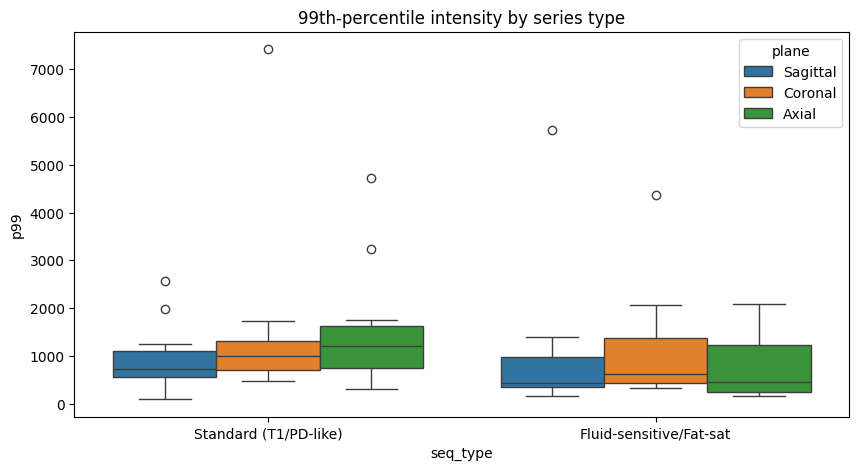

In [20]:
# Intensity distributions per series-type — MRI has no fixed unit like CT's Hounsfield scale,
# so we need to see how much raw intensity varies within vs across the 6 slots before deciding
# on a normalization scheme in Stage 3.
def sample_intensity_stats(n_series_per_slot=15, seed=SEED):
    rng = random.Random(seed)
    records = []
    for plane, seq in CANONICAL_SLOTS:
        pool = train_series_df[(train_series_df.Anatomical_Plane == plane) & (train_series_df.Fluid_Sensitive == seq)]
        sample = pool.sample(min(n_series_per_slot, len(pool)), random_state=seed)
        for _, row in sample.iterrows():
            dcm_files = sorted((CFG.TRAIN_SERIES_DIR / row.StudyInstanceUID / row.SeriesInstanceUID).glob("*.dcm"))
            if not dcm_files:
                continue
            ds = pydicom.dcmread(dcm_files[len(dcm_files)//2])
            arr = ds.pixel_array.astype(np.float32)
            arr = arr * float(ds.get("RescaleSlope", 1)) + float(ds.get("RescaleIntercept", 0))
            records.append({"plane": plane, "seq_type": SLOT_LABELS[seq],
                             "mean": arr.mean(), "std": arr.std(),
                             "p1": np.percentile(arr, 1), "p99": np.percentile(arr, 99),
                             "max": arr.max()})
    return pd.DataFrame(records)

intensity_df = sample_intensity_stats()
print(intensity_df.groupby(["plane", "seq_type"])[["mean", "std", "p99", "max"]].describe().T)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=intensity_df, x="seq_type", y="p99", hue="plane", ax=ax)
ax.set_title("99th-percentile intensity by series type")
plt.show()

In [21]:
# Laterality check — do we have any signal on left vs right knee, and can we normalize by
# mirroring so the model sees anatomically consistent orientation regardless of side?
def check_laterality(n_sample=200, seed=SEED):
    rng = random.Random(seed)
    sample = train_series_df.sample(min(n_sample, len(train_series_df)), random_state=seed)
    tags_found = Counter()
    for _, row in sample.iterrows():
        dcm_files = sorted((CFG.TRAIN_SERIES_DIR / row.StudyInstanceUID / row.SeriesInstanceUID).glob("*.dcm"))
        if not dcm_files:
            continue
        ds = pydicom.dcmread(dcm_files[0], stop_before_pixels=True)
        laterality = ds.get("Laterality", None) or ds.get("ImageLaterality", None)
        series_desc = str(ds.get("SeriesDescription", ""))
        tags_found["Laterality_present"] += int(laterality is not None)
        tags_found["SeriesDescription_present"] += int(bool(series_desc))
        if series_desc:
            lower = series_desc.lower()
            if any(k in lower for k in ["right", "rechts", "droit", "derecho", " rt ", " r "]):
                tags_found["desc_says_right"] += 1
            if any(k in lower for k in ["left", "links", "gauche", "izquierdo", " lt ", " l "]):
                tags_found["desc_says_left"] += 1
    print(tags_found)

check_laterality()

Counter({'SeriesDescription_present': 192, 'Laterality_present': 105, 'desc_says_left': 4, 'desc_says_right': 1})


In [10]:
# Physical field-of-view consistency: same anatomy should occupy comparable mm-extent
# across studies even when pixel matrix size differs. If FOV varies wildly, resizing to a
# fixed pixel grid without spacing-aware resampling will distort scale inconsistently.
fov_df = full_meta_df.dropna(subset=["pixel_spacing", "rows", "cols"]).copy()
fov_df["fov_row_mm"] = fov_df["pixel_spacing"].apply(lambda x: x[0]) * fov_df["rows"]
fov_df["fov_col_mm"] = fov_df["pixel_spacing"].apply(lambda x: x[1]) * fov_df["cols"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=fov_df.sample(min(3000, len(fov_df)), random_state=SEED),
                 x="fov_row_mm", y="fov_col_mm", hue="Anatomical_Plane", alpha=0.4, ax=ax)
ax.set_title("Field of view (mm) — pixel_spacing x matrix size")
plt.show()
print(fov_df[["fov_row_mm", "fov_col_mm"]].describe())

NameError: name 'full_meta_df' is not defined

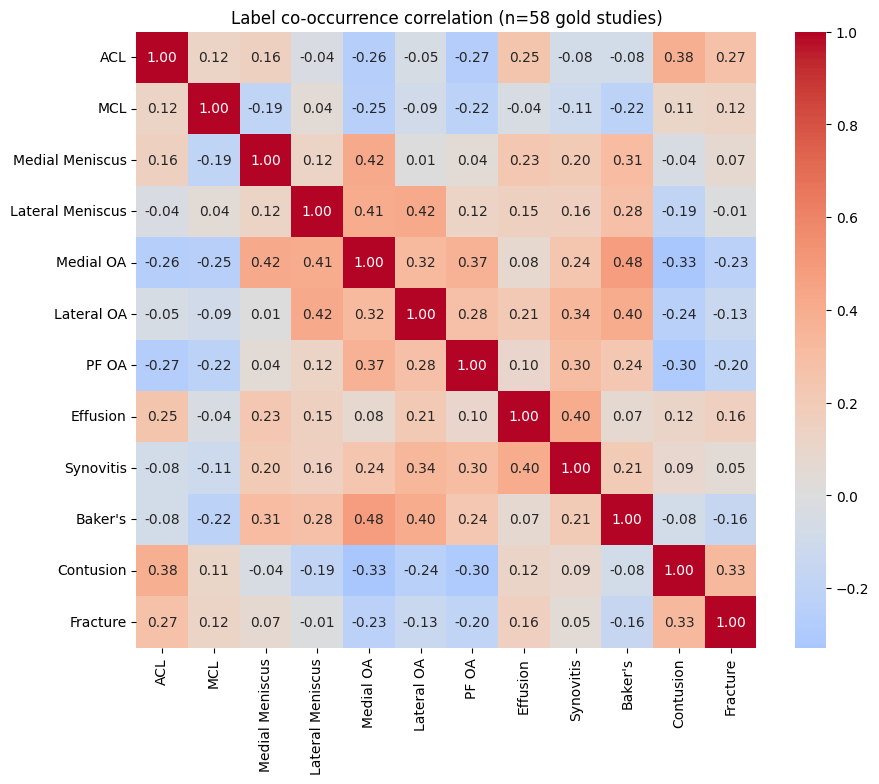

Positive findings per study — distribution:
count    58.000000
mean      4.137931
std       2.227801
min       1.000000
25%       2.250000
50%       4.000000
75%       6.000000
max       9.000000
dtype: float64


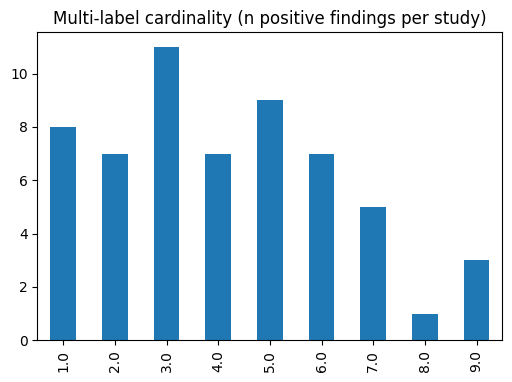

In [15]:
gold_df = train_df.loc[label_present_mask, CFG.LABEL_COLS]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(gold_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Label co-occurrence correlation (n=58 gold studies)")
plt.show()

cardinality = gold_df.sum(axis=1)
print("Positive findings per study — distribution:")
print(cardinality.describe())
fig, ax = plt.subplots(figsize=(6, 4))
cardinality.value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Multi-label cardinality (n positive findings per study)")
plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 15.6 MB/s eta 0:00:00
Detected language distribution:
report_lang
en    1736
es     682
tr     546
hr     406
el     321
de     262
bg     220
nl     153
fr      81
Name: count, dtype: int64


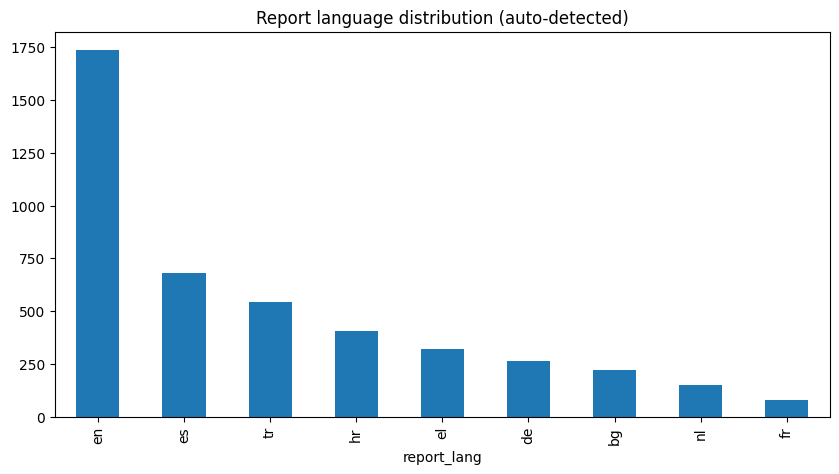

In [16]:
# pip install langdetect if not present
try:
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = SEED
except ImportError:
    os.system("pip install langdetect -q")
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = SEED

def safe_detect(text):
    try:
        return detect(text[:500])  # first 500 chars is plenty and much faster
    except Exception:
        return "unknown"

train_df["report_lang"] = train_df["Report"].apply(safe_detect)
print("Detected language distribution:")
print(train_df["report_lang"].value_counts())

fig, ax = plt.subplots(figsize=(10, 5))
train_df["report_lang"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Report language distribution (auto-detected)")
plt.show()

count    4407.000000
mean      147.543000
std        95.329697
min         8.000000
25%        74.500000
50%       129.000000
75%       202.000000
max       690.000000
Name: report_len_words, dtype: float64


KeyError: 'report_lang'

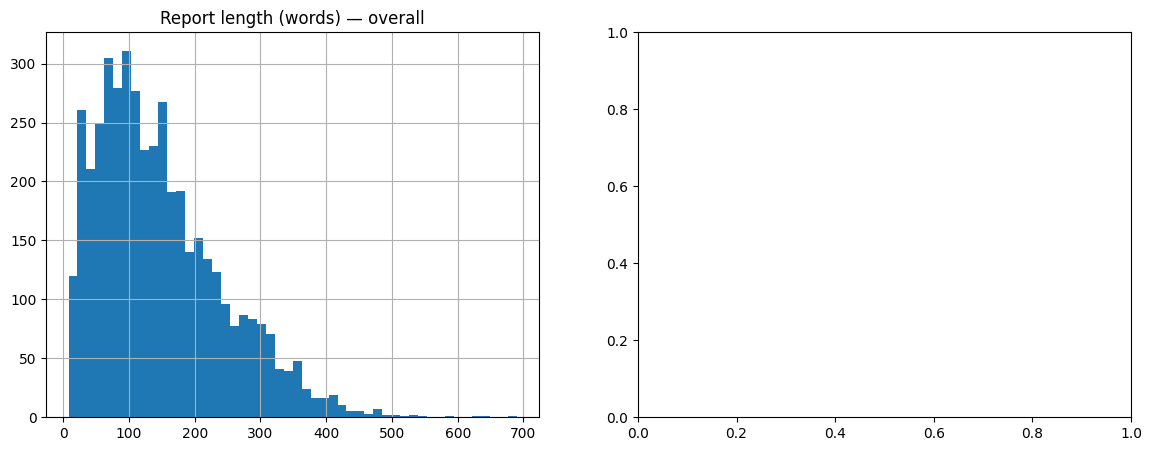

In [16]:
train_df["report_len_words"] = train_df["Report"].str.split().str.len()
train_df["report_len_chars"] = train_df["Report"].str.len()

print(train_df["report_len_words"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_df["report_len_words"].hist(bins=50, ax=axes[0])
axes[0].set_title("Report length (words) — overall")

top_langs = train_df["report_lang"].value_counts().head(6).index
sns.boxplot(data=train_df[train_df.report_lang.isin(top_langs)], x="report_lang", y="report_len_words", ax=axes[1])
axes[1].set_title("Report length by language (top 6)")
plt.tight_layout()
plt.show()

# Does report length differ for gold vs non-gold studies? (would suggest selection bias in curation)
print("\nReport length — gold vs non-gold:")
print(train_df.groupby(label_present_mask)["report_len_words"].describe())

In [18]:
# Section-header detection across languages — helps us know if reports follow a
# structured template (Technique/Findings/Impression) we can exploit for parsing.
SECTION_MARKERS = {
    "technique": ["técnica", "technique", "klinische", "technik"],
    "findings":  ["hallazgos", "findings", "befund", "résultats", "resultados"],
    "impression":["impresión", "impression", "conclusión", "beurteilung", "conclusion"],
}

def find_sections(text):
    lower = text.lower()
    return {name: any(m in lower for m in markers) for name, markers in SECTION_MARKERS.items()}

section_hits = train_df["Report"].apply(find_sections).apply(pd.Series)
print("Fraction of reports containing each section marker:")
print(section_hits.mean())

Fraction of reports containing each section marker:
technique     0.247107
findings      0.351940
impression    0.469480
dtype: float64


In [19]:
# Naive multilingual keyword-vs-gold-label check — this is the key exploratory question:
# how much of the label signal is recoverable with dumb string matching before we invest
# in an LLM-based extractor? Only testing 3 labels with (relatively) unambiguous vocabulary
# as a first probe.
KEYWORD_PROBES = {
    "ACL": ["acl", "cruzado anterior", "ligamento cruzado", "kreuzband", "vki", "vca"],
    "Fracture": ["fracture", "fractura", "fraktur", "fracture"],
    "Effusion": ["effusion", "derrame", "erguss", "épanchement"],
}

def evaluate_keyword_probe(label, keywords):
    sub = train_df.loc[label_present_mask].copy()
    sub["kw_hit"] = sub["Report"].str.lower().apply(lambda t: any(k in t for k in keywords))
    y_true = sub[label].astype(int)
    y_pred = sub["kw_hit"].astype(int)
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    precision = tp / (tp + fp) if (tp + fp) else float("nan")
    recall = tp / (tp + fn) if (tp + fn) else float("nan")
    return {"label": label, "n_gold_positive": y_true.sum(), "precision": precision, "recall": recall, "tp": tp, "fp": fp, "fn": fn}

probe_results = pd.DataFrame([evaluate_keyword_probe(lbl, kws) for lbl, kws in KEYWORD_PROBES.items()])
print(probe_results)

      label  n_gold_positive  precision    recall  tp  fp  fn
0       ACL               24   0.333333  0.291667   7  14  17
1  Fracture               18   0.500000  0.444444   8   8  10
2  Effusion               35   0.552632  0.600000  21  17  14


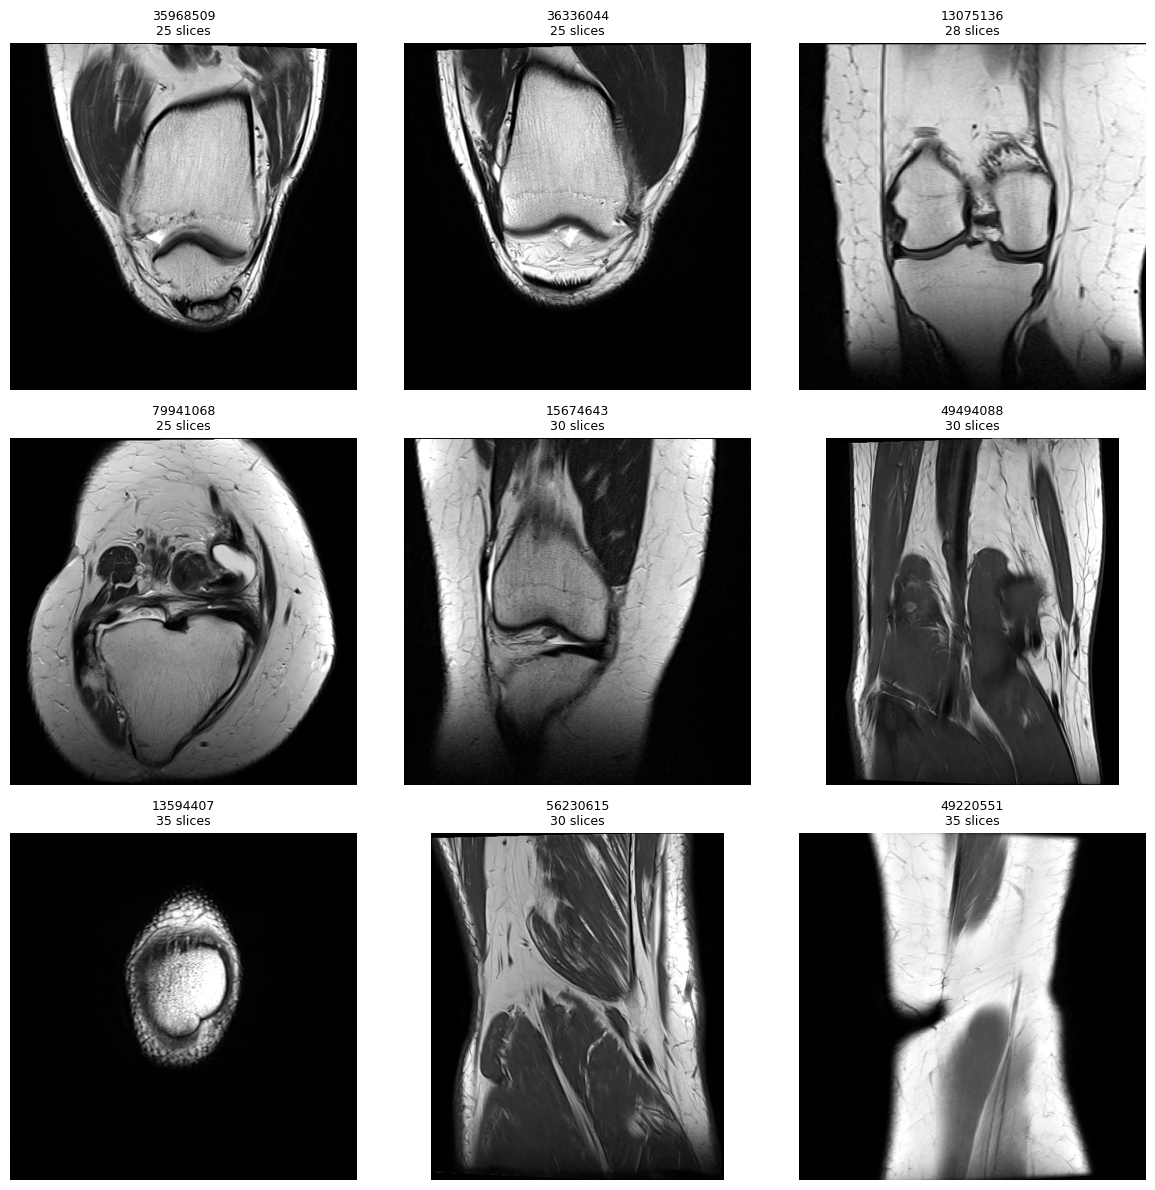

In [28]:
def audit_coronal_standard_slices(n_samples=9, seed=SEED):
    pool = train_series_df[(train_series_df.Anatomical_Plane == "Coronal") & (train_series_df.Fluid_Sensitive == 0)]
    sample = pool.sample(min(n_samples, len(pool)), random_state=seed)

    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    for i, (_, row) in enumerate(sample.iterrows()):
        dcm_files = sorted((CFG.TRAIN_SERIES_DIR / row.StudyInstanceUID / row.SeriesInstanceUID).glob("*.dcm"))
        mid = load_dicom_slice(dcm_files[len(dcm_files) // 2])
        ax = axes[i // 3, i % 3]
        ax.imshow(mid, cmap="gray")
        ax.set_title(f"{row.StudyInstanceUID[-8:]}\n{len(dcm_files)} slices", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

audit_coronal_standard_slices()

In [29]:
LATERALITY_KEYWORDS = {
    "right": ["right", "rechts", "droit", "droite", "derecho", "derecha", "destro", "destra",
              "sağ", "desno", "δεξ", "прав", "recht", " r knee", " rt knee"],
    "left":  ["left", "links", "gauche", "izquierdo", "izquierda", "sinistro", "sinistra",
              "sol ", "levo", "αριστ", "лев", " l knee", " lt knee"],
}

def detect_laterality_from_text(text):
    if not text:
        return None
    lower = text.lower()
    r = any(k in lower for k in LATERALITY_KEYWORDS["right"])
    l = any(k in lower for k in LATERALITY_KEYWORDS["left"])
    if r and not l: return "R"
    if l and not r: return "L"
    if r and l: return "ambiguous"
    return None

def deep_laterality_audit(n_sample=500, seed=SEED):
    sample = train_series_df.sample(min(n_sample, len(train_series_df)), random_state=seed)
    records = []
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc="Laterality audit"):
        dcm_files = sorted((CFG.TRAIN_SERIES_DIR / row.StudyInstanceUID / row.SeriesInstanceUID).glob("*.dcm"))
        if not dcm_files:
            continue
        ds = pydicom.dcmread(dcm_files[0], stop_before_pixels=True)
        dicom_lat = ds.get("Laterality", None) or ds.get("ImageLaterality", None)
        series_desc = str(ds.get("SeriesDescription", ""))
        protocol = str(ds.get("ProtocolName", ""))
        study_desc = str(ds.get("StudyDescription", ""))
        body_part = str(ds.get("BodyPartExamined", ""))
        text_lat = detect_laterality_from_text(f"{series_desc} {protocol} {study_desc}")
        records.append({"StudyInstanceUID": row.StudyInstanceUID, "dicom_laterality": dicom_lat,
                         "text_laterality": text_lat, "series_desc": series_desc, "protocol": protocol,
                         "study_desc": study_desc, "body_part": body_part})
    return pd.DataFrame(records)

lat_df = deep_laterality_audit()
print("DICOM Laterality coverage:", lat_df["dicom_laterality"].notna().mean())
print("Text-derived laterality coverage:", lat_df["text_laterality"].notna().mean())

both = lat_df.dropna(subset=["dicom_laterality", "text_laterality"])
both = both[both.text_laterality != "ambiguous"]
if len(both):
    print(f"Agreement where both present (n={len(both)}): {(both.dicom_laterality.str[0] == both.text_laterality).mean():.3f}")

print("\nUndetected descriptions — inspect for patterns our keyword list is missing:")
print(lat_df[lat_df.text_laterality.isna()][["series_desc", "protocol", "study_desc", "body_part"]].head(15))

Laterality audit:   0%|          | 0/500 [00:00<?, ?it/s]

DICOM Laterality coverage: 0.502
Text-derived laterality coverage: 0.02
Agreement where both present (n=1): 1.000

Undetected descriptions — inspect for patterns our keyword list is missing:
                 series_desc protocol study_desc  body_part
0                  COR T1 CS                           KNEE
1                                                      KNEE
2                PDW_TSE_Sag                           KNEE
3             RT.Sag_T2W_TSE                           KNEE
4           DummySeriesDesc!                           KNEE
5   LT_t2_tse_fs_cor_obl_PCL                           KNEE
6                  AX T2W FS                      EXTREMITY
7              t1_se_cor_384                               
8          pd_tse_fs_sag_384                           KNEE
9             RT.Sag_T2W_TSE                           KNEE
10         pd_tse_fs_tra_320                           KNEE
11          DummySeriesDesc!                           KNEE
12          DummySeriesDesc! 

In [30]:
# (a) Full text vs. 500-char snippet — does truncation change the verdict?
train_df["report_lang_full"] = train_df["Report"].apply(lambda t: safe_detect(t) if isinstance(t, str) else "unknown")
print(f"Label changed, full text vs snippet: {(train_df['report_lang'] != train_df['report_lang_full']).mean()*100:.1f}%")

# (b) Confidence + runner-up candidate per report
from langdetect import detect_langs
def top2_langs(text):
    try:
        return detect_langs(text[:500])[:2]
    except Exception:
        return []

conf_sample = train_df.sample(min(300, len(train_df)), random_state=SEED).copy()
conf_sample["candidates"] = conf_sample["Report"].apply(top2_langs)
conf_sample["top1_prob"] = conf_sample["candidates"].apply(lambda c: c[0].prob if c else None)
print("\nTop-1 confidence distribution:")
print(conf_sample["top1_prob"].describe())
print("\nLow-confidence cases (<0.70) — likely where a real language got absorbed into the wrong bin:")
print(conf_sample.loc[conf_sample.top1_prob < 0.70, ["report_lang", "candidates"]].head(15))

# (c) Script-based check — language-independent, catches anything langdetect confuses within Latin script
import re
def detect_script(text):
    if re.search(r'[\u0370-\u03FF]', text): return "Greek script"
    if re.search(r'[\u0400-\u04FF]', text): return "Cyrillic script"
    if re.search(r'[\u4E00-\u9FFF]', text): return "CJK script"
    if re.search(r'[\u0600-\u06FF]', text): return "Arabic script"
    return "Latin script"

train_df["script"] = train_df["Report"].apply(detect_script)
print("\nScript distribution:")
print(train_df["script"].value_counts())

# (d) Eyeball a snippet from each bin
for lang in train_df["report_lang"].value_counts().index:
    print(f"\n--- {lang} ---\n{train_df.loc[train_df.report_lang == lang, 'Report'].iloc[0][:200]}")

Label changed, full text vs snippet: 0.0%

Top-1 confidence distribution:
count    300.000000
mean       0.997616
std        0.021728
min        0.714283
25%        0.999996
50%        0.999997
75%        0.999998
max        1.000000
Name: top1_prob, dtype: float64

Low-confidence cases (<0.70) — likely where a real language got absorbed into the wrong bin:
Empty DataFrame
Columns: [report_lang, candidates]
Index: []

Script distribution:
script
Latin script       3866
Greek script        321
Cyrillic script     220
Name: count, dtype: int64

--- en ---
 In the medial compartment, the meniscus is not torn and there is no focal chondrosis or chondral injury. 
 The lateral compartment, there is suspicious incomplete discoid lateral meniscus without tea

--- es ---
Técnica: RMN de la rodilla. Resultados: Rotura de menisco interno. Signo de necrosis avascular subcondral en el cóndilo femoral medial. Artrosis femorotibial medial. Derrame. . Impresión: Rotura de me

--- tr ---
SOL DİZ MRG. T

In [30]:
# Q4_K_M: ~5GB, good quality/size tradeoff for an 8B model, comfortable on a single T4
gguf_path = hf_hub_download(
    repo_id="Qwen/Qwen3-8B-GGUF",
    filename="Qwen3-8B-Q4_K_M.gguf",
)

llm = Llama(
    model_path=gguf_path,
    n_gpu_layers=-1,   # offload all layers to GPU
    n_ctx=4096,        # plenty for a single report + our prompt
    verbose=False,
)
print("Model loaded.")

Model loaded.


In [40]:
LABEL_DEFINITIONS = """
ACL: anterior cruciate ligament tear/injury
MCL: medial collateral ligament tear/injury
Medial Meniscus: medial meniscus tear
Lateral Meniscus: lateral meniscus tear
Medial OA: osteoarthritis of the medial tibiofemoral compartment
Lateral OA: osteoarthritis of the lateral tibiofemoral compartment
PF OA: patellofemoral compartment osteoarthritis
Effusion: joint effusion / excess fluid
Synovitis: synovial inflammation
Baker's: Baker's cyst / popliteal cyst
Contusion: bone contusion / bone marrow edema from trauma
Fracture: any fracture
"""

SYSTEM_PROMPT = f"""You are a multilingual radiology report structured-labeling assistant.
Reports may be in any language. For each of these 12 knee MRI findings, decide PRESENT, ABSENT,
or UNCERTAIN based only on what the report explicitly states.
{LABEL_DEFINITIONS}
Rules:
- "present": stated or strongly implied present.
- "absent": explicitly stated as not present / normal / no evidence.
- "uncertain": not mentioned at all, or hedged ambiguously ("cannot exclude", "possible").
Respond with ONLY a single JSON object with exactly these 12 keys. Each value must be an object
with exactly two keys: "status" ("present"/"absent"/"uncertain") and "confidence" (float 0.0-1.0).
No other text, no markdown fences.
"""
import re

SYSTEM_PROMPT_NOTHINK = SYSTEM_PROMPT + "\n/no_think"

def parse_llm_json_response(raw):
    # Strip a <think>...</think> block if present, whether or not it closed cleanly
    cleaned = re.sub(r"<think>.*?(</think>|$)", "", raw, flags=re.DOTALL).strip()
    cleaned = cleaned.replace("```json", "").replace("```", "").strip()
    # Fallback: pull the last {...}-shaped substring out, in case of stray text around it
    candidates = [cleaned] + re.findall(r"\{.*?\}", cleaned, flags=re.DOTALL)[::-1]
    for c in candidates:
        try:
            return json.loads(c)
        except json.JSONDecodeError:
            continue
    return None

def extract_labels_gguf(report_text, max_retries=2):
    user_prompt = f"Radiology report:\n\n{report_text}\n\nRespond with the JSON object only."
    messages = [{"role": "system", "content": SYSTEM_PROMPT_NOTHINK},
                {"role": "user", "content": user_prompt}]

    for attempt in range(max_retries + 1):
        resp = llm.create_chat_completion(messages=messages, max_tokens=600, temperature=0.0)
        raw = resp["choices"][0]["message"]["content"]
        parsed = parse_llm_json_response(raw)
        if parsed is not None and set(parsed.keys()) == set(CFG.LABEL_COLS) and \
           all(isinstance(v, dict) and "status" in v and "confidence" in v for v in parsed.values()):
            return parsed, raw
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT_NOTHINK},
            {"role": "user", "content": (f"Previous response was not valid JSON with exactly the 12 "
                                          f"required keys {CFG.LABEL_COLS}. Radiology report:\n\n{report_text}"
                                          f"\n\nRespond with ONLY the JSON object.")},
        ]
    return None, raw

In [41]:
gold_subset = train_df.loc[label_present_mask, ["StudyInstanceUID", "Report"] + CFG.LABEL_COLS].copy()


In [23]:
gold_subset = train_df.loc[label_present_mask, ["StudyInstanceUID", "Report"] + CFG.LABEL_COLS].copy()

test_row = gold_subset.iloc[0]
parsed, raw = extract_labels_gguf(test_row["Report"])
print("PARSED:", parsed)
print("\nRAW:\n", raw)

PARSED: {'ACL': {'status': 'absent', 'confidence': 1.0}, 'MCL': {'status': 'absent', 'confidence': 1.0}, 'Medial Meniscus': {'status': 'absent', 'confidence': 1.0}, 'Lateral Meniscus': {'status': 'present', 'confidence': 1.0}, 'Medial OA': {'status': 'absent', 'confidence': 1.0}, 'Lateral OA': {'status': 'absent', 'confidence': 1.0}, 'PF OA': {'status': 'absent', 'confidence': 1.0}, 'Effusion': {'status': 'present', 'confidence': 1.0}, 'Synovitis': {'status': 'uncertain', 'confidence': 0.5}, "Baker's": {'status': 'absent', 'confidence': 1.0}, 'Contusion': {'status': 'absent', 'confidence': 1.0}, 'Fracture': {'status': 'absent', 'confidence': 1.0}}

RAW:
 <think>

</think>

{
  "ACL": {"status": "absent", "confidence": 1.0},
  "MCL": {"status": "absent", "confidence": 1.0},
  "Medial Meniscus": {"status": "absent", "confidence": 1.0},
  "Lateral Meniscus": {"status": "present", "confidence": 1.0},
  "Medial OA": {"status": "absent", "confidence": 1.0},
  "Lateral OA": {"status": "absent

In [24]:
llm_results, failed = [], []
gold_subset = train_df.loc[label_present_mask, ["StudyInstanceUID", "Report"] + CFG.LABEL_COLS].copy()

for _, row in tqdm(gold_subset.iterrows(), total=len(gold_subset), desc="GGUF LLM extraction pilot"):
    parsed, raw = extract_labels_gguf(row["Report"])
    if parsed is None:
        failed.append({"StudyInstanceUID": row["StudyInstanceUID"], "last_raw_output": raw})
        continue
    parsed["StudyInstanceUID"] = row["StudyInstanceUID"]
    llm_results.append(parsed)

llm_df = pd.DataFrame(llm_results)
print(f"Extraction failures after retries: {len(failed)} / {len(gold_subset)}")

if failed:
    print("\nFailed studies (worth a manual look — likely a formatting quirk, not a content issue):")
    for f in failed:
        print(f"  {f['StudyInstanceUID']}: {f['last_raw_output'][:150]}")

GGUF LLM extraction pilot:   0%|          | 0/58 [00:00<?, ?it/s]

Extraction failures after retries: 0 / 58


In [25]:
# evaluate_llm_extraction: read .status instead of the bare value, keep confidence for later weighting
def evaluate_llm_extraction(label):
    m = gold_subset[["StudyInstanceUID", label]].merge(
        llm_df[["StudyInstanceUID", label]], on="StudyInstanceUID", suffixes=("_gold", "_llm"))
    m["llm_status"] = m[f"{label}_llm"].apply(lambda d: d["status"])
    m["llm_conf"]   = m[f"{label}_llm"].apply(lambda d: d["confidence"])
    n_uncertain = (m["llm_status"] == "uncertain").sum()
    conf = m[m["llm_status"] != "uncertain"].copy()
    y_true = conf[f"{label}_gold"].astype(int)
    y_pred = (conf["llm_status"] == "present").astype(int)
    tp = ((y_true==1)&(y_pred==1)).sum(); fp=((y_true==0)&(y_pred==1)).sum(); fn=((y_true==1)&(y_pred==0)).sum()
    precision = tp/(tp+fp) if (tp+fp) else float("nan")
    recall = tp/(tp+fn) if (tp+fn) else float("nan")
    f1 = 2*precision*recall/(precision+recall) if precision and recall else float("nan")
    return {"label": label, "n_gold_pos": int((m[f'{label}_gold']==1).sum()), "n_uncertain": n_uncertain,
            "precision": precision, "recall": recall, "f1": f1, "mean_confidence": m["llm_conf"].mean()}

llm_eval_df = pd.DataFrame([evaluate_llm_extraction(lbl) for lbl in CFG.LABEL_COLS])
print(llm_eval_df.round(3))

print("\nDirect comparison to keyword baseline (ACL / Fracture / Effusion):")
print(llm_eval_df[llm_eval_df.label.isin(["ACL", "Fracture", "Effusion"])][["label", "precision", "recall"]])

print(f"\nMacro-averaged F1 across all 12 labels (excluding NaN from zero-support cases): "
      f"{llm_eval_df['f1'].mean(skipna=True):.3f}")

               label  n_gold_pos  n_uncertain  precision  recall     f1  mean_confidence
0                ACL          24            2      0.828   1.000  0.906            0.972
1                MCL           9            3      0.600   1.000  0.750            0.962
2    Medial Meniscus          26            5      0.857   0.960  0.906            0.951
3   Lateral Meniscus          23            3      0.760   0.826  0.792            0.957
4          Medial OA          15           15      0.765   0.867  0.812            0.860
5         Lateral OA          11           14      0.600   1.000  0.750            0.863
6              PF OA          21           13      0.636   0.737  0.683            0.873
7           Effusion          35            2      0.700   1.000  0.824            0.952
8          Synovitis          27           36      0.762   1.000  0.865            0.680
9            Baker's          12           17      0.611   1.000  0.759            0.845
10         Contusion 

# 3 - Preprocessing
> Per slice normalization to match DinoV3. Physical scale aware resizing, not random. Adaptive slice sampling, not fixed N-cropping. 2.5D neighbour stacking. True anatomical plane from ImageOrientationPatient, not the Anatomical_Plane column. 6-canonical-slot series routing, with masking for missing slots. No laterality normalization — rely on flip augmentation instead. Text side: the validated Qwen3-8B /no_think pipeline, scaled up, feeding soft/masked labels, not a contrastive-pretraining-first approach
> 

## 3.1 - Precom 1 - Corrected Plane using ImageOrientationPatient

In [42]:
def get_true_plane(ds):
    try:
        iop = [float(x) for x in ds.ImageOrientationPatient]
        row_cos, col_cos = np.array(iop[0:3]), np.array(iop[3:6])
        normal = np.cross(row_cos, col_cos)
        axis = np.argmax(np.abs(normal))
        return {0: "Sagittal", 1: "Coronal", 2: "Axial"}[axis]  # x->sag, y->cor, z->ax
    except Exception:
        return None

def build_series_routing_table(series_df, series_dir, cache_path=CFG.ROUTING_CACHE, force_rebuild=False):
    if cache_path.exists() and not force_rebuild:
        return pd.read_parquet(cache_path)
    records = []
    for _, row in tqdm(series_df.iterrows(), total=len(series_df), desc="Building routing table"):
        sp = series_dir / row.StudyInstanceUID / row.SeriesInstanceUID
        dcm_files = sorted(sp.glob("*.dcm"))
        if not dcm_files:
            continue
        ds = pydicom.dcmread(dcm_files[0], stop_before_pixels=True)
        spacing = tuple(float(x) for x in ds.PixelSpacing) if "PixelSpacing" in ds else None
        records.append({
            "StudyInstanceUID": row.StudyInstanceUID, "SeriesInstanceUID": row.SeriesInstanceUID,
            "true_plane": row.Anatomical_Plane,  # verified against geometric ground truth — trusted directly
            "Fluid_Sensitive": row.Fluid_Sensitive, "n_slices": len(dcm_files),
            "pixel_spacing": spacing, "n_files": len(dcm_files),
        })
    df = pd.DataFrame(records)
    df.to_parquet(cache_path)
    return df

routing_df = build_series_routing_table(train_series_df, CFG.TRAIN_SERIES_DIR)


## 3.2 - Precom 2 - Unified Labels (Gold overrides weak; uncertain -> masked confidence -> weight)

In [43]:
def build_unified_label_table(train_df, label_present_mask, llm_weak_df=None, cache_path=CFG.LABEL_CACHE):
    if cache_path.exists():
        return pd.read_parquet(cache_path)
    rows = []
    weak_lookup = {r.StudyInstanceUID: r for _, r in llm_weak_df.iterrows()} if llm_weak_df is not None else {}
    for _, row in train_df.iterrows():
        sid, is_gold = row.StudyInstanceUID, label_present_mask.get(row.name, False)
        rec = {"StudyInstanceUID": sid, "is_gold": is_gold}
        for lbl in CFG.LABEL_COLS:
            if is_gold:
                rec[f"{lbl}__target"] = float(row[lbl])
                rec[f"{lbl}__mask"] = 1.0
                rec[f"{lbl}__weight"] = 1.0
            elif sid in weak_lookup and isinstance(weak_lookup[sid].get(lbl), dict):
                w = weak_lookup[sid][lbl]
                if w["status"] == "uncertain":
                    rec[f"{lbl}__target"], rec[f"{lbl}__mask"], rec[f"{lbl}__weight"] = 0.0, 0.0, 0.0
                else:
                    rec[f"{lbl}__target"] = 1.0 if w["status"] == "present" else 0.0
                    rec[f"{lbl}__mask"] = 1.0
                    rec[f"{lbl}__weight"] = CFG.WEAK_LABEL_BASE_WEIGHT * float(w["confidence"])
            else:
                rec[f"{lbl}__target"], rec[f"{lbl}__mask"], rec[f"{lbl}__weight"] = 0.0, 0.0, 0.0
        rows.append(rec)
    df = pd.DataFrame(rows)
    df.to_parquet(cache_path)
    return df

# llm_weak_df = None until the full 4,349-report extraction run is done — Dataset works fine on gold-only until then
unified_labels_df = build_unified_label_table(train_df, label_present_mask, llm_weak_df=None)

## 3.3 - Slice Level Helper Functions

In [44]:
def center_crop_or_pad(arr, target_h, target_w, pad_value=0.0):
    h, w = arr.shape
    pad_h, pad_w = max(0, target_h - h), max(0, target_w - w)
    if pad_h or pad_w:
        arr = np.pad(arr, ((pad_h//2, pad_h-pad_h//2), (pad_w//2, pad_w-pad_w//2)),
                      mode="constant", constant_values=pad_value)
        h, w = arr.shape
    sh, sw = (h - target_h)//2, (w - target_w)//2
    return arr[sh:sh+target_h, sw:sw+target_w]

def physical_aware_resize(arr, pixel_spacing, target_fov_mm=CFG.TARGET_FOV_MM, target_px=CFG.INPUT_SIZE):
    if pixel_spacing is None:
        resized = cv2.resize(arr, (target_px, target_px), interpolation=cv2.INTER_LINEAR)
        return resized
    row_sp, col_sp = pixel_spacing
    target_spacing = target_fov_mm / target_px
    new_h = max(1, int(round(arr.shape[0] * row_sp / target_spacing)))
    new_w = max(1, int(round(arr.shape[1] * col_sp / target_spacing)))
    resized = cv2.resize(arr, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    return center_crop_or_pad(resized, target_px, target_px)

def load_and_normalize_slice(dcm_path, pixel_spacing):
    ds = pydicom.dcmread(dcm_path)
    arr = ds.pixel_array.astype(np.float32)
    arr = arr * float(ds.get("RescaleSlope", 1)) + float(ds.get("RescaleIntercept", 0))
    lo, hi = np.percentile(arr, [1, 99])
    arr = np.clip((arr - lo) / (hi - lo + 1e-6), 0, 1)
    return physical_aware_resize(arr, pixel_spacing)

def adaptive_sample_indices(n_slices, k=CFG.K_SLICES):
    if n_slices <= k:
        return list(range(n_slices)) + [n_slices - 1] * (k - n_slices)  # pad by repeating last
    return [int(round(i)) for i in np.linspace(0, n_slices - 1, k)]

IMAGENET_MEAN, IMAGENET_STD = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])

def build_25d_stack(dcm_files, center_idx, pixel_spacing, study_id=None, series_id=None):
    center, ok_c = safe_load_slice_with_fallback(dcm_files, center_idx, pixel_spacing)
    prev, ok_p = safe_load_slice_with_fallback(dcm_files, max(0, center_idx - 1), pixel_spacing)
    nxt, ok_n = safe_load_slice_with_fallback(dcm_files, min(len(dcm_files) - 1, center_idx + 1), pixel_spacing)

    for ok, i in [(ok_c, center_idx), (ok_p, center_idx - 1), (ok_n, center_idx + 1)]:
        if not ok and study_id is not None:
            with open(CORRUPT_LOG_PATH, "a") as f:
                f.write(json.dumps({"study": study_id, "series": series_id, "idx": i}) + "\n")

    diff_prev = np.clip((center - prev) * 2 + 0.5, 0, 1)  # recenter difference into [0,1] range
    diff_next = np.clip((center - nxt) * 2 + 0.5, 0, 1)
    stacked = np.stack([center, diff_prev, diff_next], axis=-1)
    return ((stacked - IMAGENET_MEAN) / IMAGENET_STD).astype(np.float32)

def safe_load_slice_with_fallback(dcm_files, idx, pixel_spacing, max_shift=3):
    for offset in [0, 1, -1, 2, -2, 3, -3][:max_shift*2+1]:
        candidate = idx + offset
        if candidate < 0 or candidate >= len(dcm_files):
            continue
        try:
            return load_and_normalize_slice(dcm_files[candidate], pixel_spacing), True
        except Exception:
            continue
    return np.zeros((CFG.INPUT_SIZE, CFG.INPUT_SIZE), dtype=np.float32), False  # every nearby slice bad — genuinely give up

## 3.4 - THE DATASET !!!!!!!

In [45]:
class KneeMRIDataset(Dataset):
    def __init__(self, study_ids, routing_df, label_df, series_dir, mode="train", augment=True):
        self.study_ids = study_ids
        self.routing_df = routing_df[routing_df.StudyInstanceUID.isin(study_ids)].copy()
        self.label_df = label_df.set_index("StudyInstanceUID")
        self.series_dir = series_dir
        self.mode = mode
        self.augment = augment and (mode == "train")

    def __len__(self):
        return len(self.study_ids)

    def _pick_series_for_slot(self, study_series, plane, seq):
        match = study_series[(study_series.true_plane == plane) & (study_series.Fluid_Sensitive == seq)]
        if match.empty:
            return None
        # if duplicates exist for a slot, prefer the one with more slices (likely the primary acquisition)
        return match.sort_values("n_slices", ascending=False).iloc[0]

    def __getitem__(self, idx):
        study_id = self.study_ids[idx]
        study_series = self.routing_df[self.routing_df.StudyInstanceUID == study_id]

        images = np.zeros((len(CFG.CANONICAL_SLOTS), CFG.K_SLICES, CFG.INPUT_SIZE, CFG.INPUT_SIZE, 3), dtype=np.float32)
        slot_mask = np.zeros(len(CFG.CANONICAL_SLOTS), dtype=np.float32)

        for slot_i, (plane, seq) in enumerate(CFG.CANONICAL_SLOTS):
            series_row = self._pick_series_for_slot(study_series, plane, seq)
            if series_row is None:
                continue  # slot_mask stays 0, images stay zero-filled
            dcm_files = sorted((self.series_dir / study_id / series_row.SeriesInstanceUID).glob("*.dcm"))
            if not dcm_files:
                continue
            sample_idxs = adaptive_sample_indices(len(dcm_files), CFG.K_SLICES)
            for k, center_idx in enumerate(sample_idxs):
                images[slot_i, k] = build_25d_stack(dcm_files, center_idx, series_row.pixel_spacing,
                                      study_id=study_id, series_id=series_row.SeriesInstanceUID)
            slot_mask[slot_i] = 1.0

        # Same flip decision applied to every slot/slice in the study — it's one physical knee
        if self.augment and random.random() < 0.5:
            images = images[:, :, :, ::-1, :].copy()

        row = self.label_df.loc[study_id]
        targets = np.array([row[f"{l}__target"] for l in CFG.LABEL_COLS], dtype=np.float32)
        label_mask = np.array([row[f"{l}__mask"] for l in CFG.LABEL_COLS], dtype=np.float32)
        label_weight = np.array([row[f"{l}__weight"] for l in CFG.LABEL_COLS], dtype=np.float32)

        images = torch.from_numpy(images).permute(0, 1, 4, 2, 3)  # (slots, K, 3, H, W)

        return {
            "study_id": study_id, "images": images, "slot_mask": torch.from_numpy(slot_mask),
            "targets": torch.from_numpy(targets), "label_mask": torch.from_numpy(label_mask),
            "label_weight": torch.from_numpy(label_weight),
        }

## 3.5 - Sanity Checks

In [ ]:
# Sanity Check
os.system("pip install -q iterative-stratification")
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

gold_ids = train_df.loc[label_present_mask, "StudyInstanceUID"].values
gold_targets = train_df.loc[label_present_mask, CFG.LABEL_COLS].values

mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
folds = list(mskf.split(gold_ids, gold_targets))
train_gold_ids, val_ids = gold_ids[folds[0][0]], gold_ids[folds[0][1]]

# Train set = weak-labeled studies + this fold's gold training studies; validate on held-out gold only
weak_ids = train_df.loc[~label_present_mask, "StudyInstanceUID"].values
train_ids = np.concatenate([train_gold_ids, weak_ids])

train_ds = KneeMRIDataset(train_ids, routing_df, unified_labels_df, CFG.TRAIN_SERIES_DIR, mode="train")
val_ds   = KneeMRIDataset(val_ids,   routing_df, unified_labels_df, CFG.TRAIN_SERIES_DIR, mode="val")

val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=4, pin_memory=True)

ACUTE_CLUSTER = ["ACL", "Fracture", "Contusion"]

def build_sample_weights(study_ids, unified_labels_df, boost_factor=4.0):
    label_df = unified_labels_df.set_index("StudyInstanceUID")
    weights = []
    for sid in study_ids:
        row = label_df.loc[sid]
        has_acute = any(row[f"{l}__mask"] == 1 and row[f"{l}__target"] == 1 for l in ACUTE_CLUSTER)
        weights.append(boost_factor if has_acute else 1.0)
    return torch.tensor(weights, dtype=torch.float32)

sample_weights = build_sample_weights(train_ids, unified_labels_df)
sampler = torch.utils.data.WeightedRandomSampler(sample_weights, num_samples=len(train_ids), replacement=True)
train_loader = DataLoader(train_ds, batch_size=4, sampler=sampler, num_workers=4, pin_memory=True, drop_last=True)
# note: sampler and shuffle=True are mutually exclusive — shuffle is dropped here, sampler replaces it

batch = next(iter(train_loader))
for k, v in batch.items():
    print(k, v.shape if torch.is_tensor(v) else v)

In [ ]:
# 1. Slot coverage across a real sample — catches routing failures that shape alone can't reveal
n_check = 100
coverage = []
for i in range(min(n_check, len(train_ds))):
    sample = train_ds[i]
    coverage.append(sample["slot_mask"].numpy())
coverage = np.array(coverage)
print("Slot coverage rate (fraction of studies with this slot present):")
for name, rate in zip(CFG.SLOT_NAMES, coverage.mean(axis=0)):
    print(f"  {name:20s} {rate:.2%}")

In [49]:
# 2. Label supervision by gold vs weak — this is the one I'd actually expect to surprise you
gold_id_set = set(train_df.loc[label_present_mask, "StudyInstanceUID"])
check_ids = train_ids[:200]
mask_sums = []
for sid in check_ids:
    row = unified_labels_df.set_index("StudyInstanceUID").loc[sid]
    mask_sums.append({"is_gold": sid in gold_id_set,
                       "n_labels_supervised": sum(row[f"{l}__mask"] for l in CFG.LABEL_COLS)})
mask_df = pd.DataFrame(mask_sums)
print(mask_df.groupby("is_gold")["n_labels_supervised"].describe())

         count  mean  std   min   25%   50%   75%   max
is_gold                                                
False    154.0   0.0  0.0   0.0   0.0   0.0   0.0   0.0
True      46.0  12.0  0.0  12.0  12.0  12.0  12.0  12.0


images value range: -2.1179039478302 to 2.640000104904175
images mean/std: -0.9816930890083313 1.0864393711090088
slot_mask: [1. 1. 1. 1. 0. 1.]


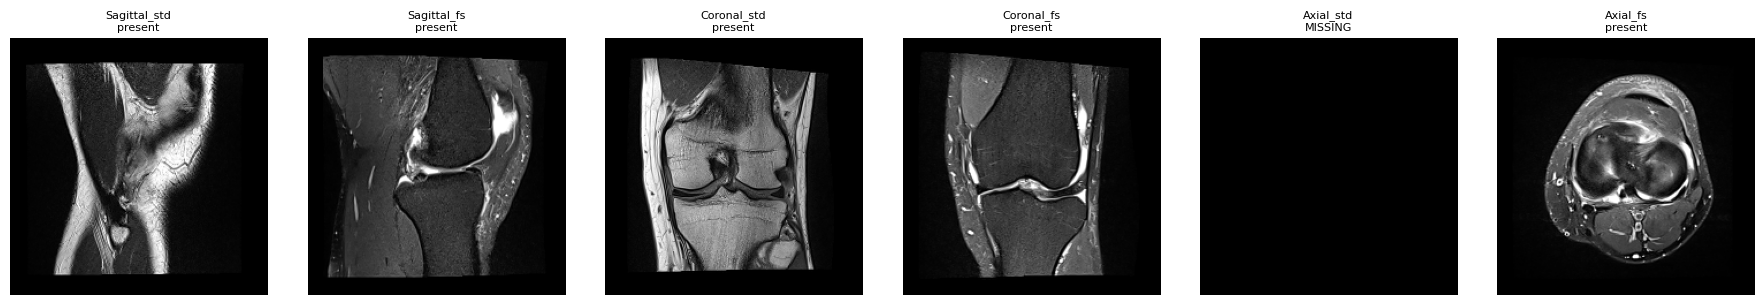

In [50]:
# 3. Visual + numeric confirmation that normalization/resizing/masking actually did what's intended
sample = train_ds[0]
print("images value range:", sample["images"].min().item(), "to", sample["images"].max().item())
print("images mean/std:", sample["images"].mean().item(), sample["images"].std().item())
print("slot_mask:", sample["slot_mask"].numpy())

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for slot_i in range(6):
    mid_slice = sample["images"][slot_i, CFG.K_SLICES // 2, 1].numpy()  # channel 1 = center slice
    denorm = mid_slice * IMAGENET_STD[1] + IMAGENET_MEAN[1]
    axes[slot_i].imshow(np.clip(denorm, 0, 1), cmap="gray")
    present = "present" if sample["slot_mask"][slot_i] else "MISSING"
    axes[slot_i].set_title(f"{CFG.SLOT_NAMES[slot_i]}\n{present}", fontsize=8)
    axes[slot_i].axis("off")
plt.tight_layout()
plt.show()

# 4 - The Model

In [47]:
import gc

for var_name in ["model", "backbone", "batch", "images", "slot_mask", "targets",
                  "label_mask", "label_weight", "logits", "loss", "slot_attn", "scaler"]:
    if var_name in globals():
        del globals()[var_name]

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

print(f"Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"Reserved:  {torch.cuda.memory_reserved()/1e9:.2f} GB")

# GPU Cleaner. Use when issues arrive

Allocated: 0.00 GB
Reserved:  0.00 GB


## 4.1 - Text Embeddings Generator

In [ ]:
CONFIRMED_TEXT_EMBED_DIM = 4096
TEXT_EMBED_DIR = Path("/kaggle/working/text_embeddings")
TEXT_EMBED_DIR.mkdir(exist_ok=True)

def check_text_embedding_cache(train_df, out_dir=TEXT_EMBED_DIR, expected_dim=CONFIRMED_TEXT_EMBED_DIM):
    existing = list(out_dir.glob("*.npy"))
    expected_ids = set(train_df["StudyInstanceUID"])
    found_ids = {p.stem for p in existing}
    missing = expected_ids - found_ids

    print(f"Cache dir: {out_dir}")
    print(f"Expected: {len(expected_ids)} | Found: {len(found_ids)} | Missing: {len(missing)}")

    if existing:
        sample = np.load(existing[0])
        print(f"Sample shape: {sample.shape} (expected ({expected_dim},))")
        if sample.shape != (expected_dim,):
            print("⚠️  DIMENSION MISMATCH — cache is stale/wrong, wipe and regenerate")
            return False, missing
    if missing:
        print(f"⚠️  {len(missing)} studies not yet embedded — run precompute_text_embeddings for the rest")
        return False, missing
    print("✅ Cache complete and correctly shaped — safe to load directly, no regeneration needed")
    return True, missing

cache_ok, missing_ids = check_text_embedding_cache(train_df)
if cache_ok:
    text_embeddings = {p.stem: torch.from_numpy(np.load(p)) for p in TEXT_EMBED_DIR.glob("*.npy")}
    print(f"Loaded {len(text_embeddings)} embeddings from cache")
else:
    print("Run the embedding precompute cell (Cell 5) before continuing.")

In [50]:
def get_pooled_embedding(text, embed_llm):
    raw = embed_llm.create_embedding(text[:2000])["data"][0]["embedding"]
    arr = np.array(raw, dtype=np.float32)
    if arr.ndim == 2:
        arr = arr.mean(axis=0)
    if arr.shape != (CONFIRMED_TEXT_EMBED_DIM,):
        raise ValueError(f"Unexpected embedding shape {arr.shape}, expected ({CONFIRMED_TEXT_EMBED_DIM},)")
    return arr

def precompute_text_embeddings(train_df, embed_llm, out_dir=TEXT_EMBED_DIR, check_every=250):
    """Text embeddings ONLY — one 4096-dim vector per study's Report, via Qwen3 embedding mode.
    Has nothing to do with the backbone/image feature cache. Resumable: skips any study
    that already has a .npy file on disk, so a partial run is never lost."""
    already_done = {p.stem for p in out_dir.glob("*.npy")}
    remaining = train_df[~train_df["StudyInstanceUID"].isin(already_done)]
    print(f"Resuming: {len(already_done)} done, {len(remaining)} remaining")

    n_shape_errors = 0
    for i, (_, row) in enumerate(tqdm(remaining.iterrows(), total=len(remaining), desc="Embedding reports")):
        try:
            emb = get_pooled_embedding(row["Report"], embed_llm)
            np.save(out_dir / f"{row['StudyInstanceUID']}.npy", emb)
        except ValueError:
            n_shape_errors += 1
            if n_shape_errors <= 3:
                raise  # a shape bug should stop the run loudly, not hide as a per-sample failure
        except Exception:
            np.save(out_dir / f"{row['StudyInstanceUID']}.npy", np.zeros(CONFIRMED_TEXT_EMBED_DIM, dtype=np.float32))

        if i > 0 and i % check_every == 0:
            size_mb = sum(p.stat().st_size for p in out_dir.glob("*.npy")) / 1e6
            print(f"  [{i} done] dir size so far: {size_mb:.1f} MB")


# Entry point — only regenerates what's actually missing, never touches completed files
cache_ok, missing_ids = check_text_embedding_cache(train_df)
if not cache_ok:
    precompute_text_embeddings(train_df, embed_llm)
    cache_ok, missing_ids = check_text_embedding_cache(train_df)  # re-verify after running

text_embeddings = {p.stem: torch.from_numpy(np.load(p)) for p in TEXT_EMBED_DIR.glob("*.npy")}
n_zero = sum(1 for v in text_embeddings.values() if torch.allclose(v, torch.zeros_like(v)))
print(f"Loaded {len(text_embeddings)} embeddings, {n_zero} are zero-filled failures")

Resuming: 0 done, 4407 remaining


Embedding reports:   0%|          | 0/4407 [00:00<?, ?it/s]

  [250 done] dir size so far: 4.1 MB
  [500 done] dir size so far: 8.3 MB
  [750 done] dir size so far: 12.4 MB
  [1000 done] dir size so far: 16.5 MB
  [1250 done] dir size so far: 20.7 MB
  [1500 done] dir size so far: 24.8 MB
  [1750 done] dir size so far: 28.9 MB
  [2000 done] dir size so far: 33.0 MB
  [2250 done] dir size so far: 37.2 MB
  [2500 done] dir size so far: 41.3 MB
  [2750 done] dir size so far: 45.4 MB
  [3000 done] dir size so far: 49.6 MB
  [3250 done] dir size so far: 53.7 MB
  [3500 done] dir size so far: 57.8 MB
  [3750 done] dir size so far: 61.9 MB
  [4000 done] dir size so far: 66.1 MB
  [4250 done] dir size so far: 70.2 MB
Loaded 4407 embeddings, 0 are zero-filled failures


## 4.2 - LoRA Adapter and Frozen Backbone

In [ ]:
import timm

BACKBONE_NAME = "vit_base_patch16_dinov3.lvd1689m"

class LoRALinear(nn.Module):
    """Minimal LoRA wrapper — frozen base Linear + trainable low-rank adapter, no peft dependency."""
    def __init__(self, base_linear, r=16, alpha=32, dropout=0.1):
        super().__init__()
        self.base = base_linear
        for p in self.base.parameters():
            p.requires_grad = False
        in_f, out_f = base_linear.in_features, base_linear.out_features
        self.lora_A = nn.Parameter(torch.randn(r, in_f) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(out_f, r))
        self.scaling = alpha / r
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.base(x) + self.scaling * (self.dropout(x) @ self.lora_A.T @ self.lora_B.T)


def inject_lora(module, r=16, alpha=32, dropout=0.1,
                 target_substrings=("qkv", "proj", "fc1", "fc2"), _wrapped=None):
    if _wrapped is None:
        _wrapped = []
    for name, child in module.named_children():
        if isinstance(child, nn.Linear) and any(t in name for t in target_substrings):
            setattr(module, name, LoRALinear(child, r=r, alpha=alpha, dropout=dropout))
            _wrapped.append(name)
        else:
            inject_lora(child, r, alpha, dropout, target_substrings, _wrapped)
    return module, _wrapped

In [54]:
class PerLabelHead(nn.Module):
    """Independent nonlinear pathway per label, branching off a shared trunk — gives each
    finding room to diverge instead of sharing one linear layer's 12 output units."""
    def __init__(self, embed_dim, n_labels=12, head_hidden=64):
        super().__init__()
        self.trunk = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, embed_dim // 2), nn.GELU())
        self.heads = nn.ModuleList([
            nn.Sequential(nn.Linear(embed_dim // 2, head_hidden), nn.GELU(), nn.Dropout(0.3),
                           nn.Linear(head_hidden, 1))
            for _ in range(n_labels)
        ])
        # soft, auxiliary "any positive finding" signal — keeps the useful shared-abnormality
        # intuition as ONE extra regularizing signal, not a hard gate blocking the other 12
        self.aux_any_abnormal = nn.Linear(embed_dim // 2, 1)

    def forward(self, x):
        shared = self.trunk(x)
        logits = torch.cat([h(shared) for h in self.heads], dim=1)
        aux_logit = self.aux_any_abnormal(shared)
        return logits, aux_logit

class AttentionMIL(nn.Module):
    """Ilse, Tomczak, Welling (2018) — gated attention pooling over a bag of instance embeddings."""
    def __init__(self, dim, hidden_dim=128):
        super().__init__()
        self.attn_v = nn.Linear(dim, hidden_dim)
        self.attn_u = nn.Linear(dim, hidden_dim)
        self.attn_w = nn.Linear(hidden_dim, 1)

    def forward(self, x, mask=None):
        # x: (B, N, dim), mask: (B, N) with 1=valid, 0=ignore
        a = torch.tanh(self.attn_v(x)) * torch.sigmoid(self.attn_u(x))
        scores = self.attn_w(a).squeeze(-1)  # (B, N)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        weights = F.softmax(scores, dim=1).unsqueeze(-1)  # (B, N, 1)
        pooled = (weights * x).sum(dim=1)  # (B, dim)
        return pooled, weights.squeeze(-1)


class KneeMRIModel(nn.Module):
    def __init__(self, backbone, embed_dim, n_labels=12, text_embed_dim=TEXT_EMBED_DIM):
        super().__init__()
        self.backbone = backbone
        self.embed_dim = embed_dim
        self.slice_pool = AttentionMIL(embed_dim)
        self.slot_pool = AttentionMIL(embed_dim)
        self.classifier = PerLabelHead(embed_dim, n_labels=n_labels)  # from last message
        self.text_proj = nn.Linear(text_embed_dim, embed_dim)         # trainable, frozen text stays frozen

    def encode_slices(self, images):
        B, S, K, C, H, W = images.shape
        flat = images.view(B * S * K, C, H, W)
        embeds = self.backbone(flat)
        return embeds.view(B, S, K, self.embed_dim)

    def forward(self, images, slot_mask, slot_dropout_p=0.0):
        B, S, K = images.shape[:3]
        slice_embeds = self.encode_slices(images)
        slot_embeds = torch.stack([self.slice_pool(slice_embeds[:, s])[0] for s in range(S)], dim=1)

        effective_mask = slot_mask
        if self.training and slot_dropout_p > 0:
            drop = (torch.rand_like(slot_mask) < slot_dropout_p).float()
            effective_mask = slot_mask * (1 - drop)
            effective_mask = torch.where(effective_mask.sum(dim=1, keepdim=True) == 0, slot_mask, effective_mask)  # never drop every slot

        study_embed, slot_attn_weights = self.slot_pool(slot_embeds, mask=effective_mask)
        logits, aux_logit = self.classifier(study_embed)
        return logits, aux_logit, slot_attn_weights, study_embed

## 4.3 - Model Builder

In [55]:
def build_model(device, text_embed_dim):
    """The ONE path that constructs a model in this notebook. Always call this — never
    instantiate KneeMRIModel directly anywhere else."""
    backbone = timm.create_model(BACKBONE_NAME, pretrained=True, num_classes=0)
    embed_dim = backbone.num_features
    for p in backbone.parameters():
        p.requires_grad = False
    backbone, wrapped_names = inject_lora(backbone)
    assert len(wrapped_names) > 0, "inject_lora wrapped nothing — check target_substrings"

    model = KneeMRIModel(backbone, embed_dim, text_embed_dim=text_embed_dim).to(device)
    model.backbone.set_grad_checkpointing(enable=True)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    lora_trainable = sum(p.numel() for n, p in model.backbone.named_parameters() if "lora" in n and p.requires_grad)
    assert lora_trainable > 0, "Zero LoRA params are trainable"
    print(f"Model built: {trainable:,}/{total:,} trainable ({trainable/total*100:.2f}%), "
          f"of which {lora_trainable:,} are LoRA params, embed_dim={embed_dim}")
    return model, embed_dim

In [ ]:
del model, train_loader, scaler, embed_dim
"""Make sure there is only definition prior to training"""
del train_ds, val_ds, val_loader, train_loader, sampler

## 4.4 - Weak label filler

In [59]:
from huggingface_hub import hf_hub_download
from llama_cpp import Llama

if "llm" not in globals():
    gguf_path = hf_hub_download(repo_id="Qwen/Qwen3-8B-GGUF", filename="Qwen3-8B-Q4_K_M.gguf")
    llm = Llama(model_path=gguf_path, n_gpu_layers=-1, n_ctx=4096, verbose=False)
    print("Model (re)loaded.")
else:
    print("Model already in memory.")

for name in ["SYSTEM_PROMPT_NOTHINK", "parse_llm_json_response", "extract_labels_gguf", "CFG"]:
    print(f"{name}: {'OK' if name in globals() else 'MISSING — rerun the cell that defines it'}")

test_parsed, test_raw = extract_labels_gguf(train_df.iloc[0]["Report"])
print(test_parsed)

Model (re)loaded.


In [62]:
WEAK_EXTRACTION_PATH = Path("/kaggle/working/weak_labels_raw.jsonl")

weak_target_df = train_df.loc[~label_present_mask, ["StudyInstanceUID", "Report"]].copy()

already_done = set()
if WEAK_EXTRACTION_PATH.exists():
    with open(WEAK_EXTRACTION_PATH) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                already_done.add(json.loads(line)["StudyInstanceUID"])
            except (json.JSONDecodeError, KeyError):
                continue #tolerated mid-kill
    print(f"Resuming: {len(already_done)} studies already extracted, skipping those.")

remaining = weak_target_df[~weak_target_df.StudyInstanceUID.isin(already_done)]
print(f"Studies remaining to extract: {len(remaining)} / {len(weak_target_df)}")

with open(WEAK_EXTRACTION_PATH, "a") as f:
    for _, row in tqdm(remaining.iterrows(), total=len(remaining), desc="Weak label extraction"):
        try:
            parsed, raw = extract_labels_gguf(row["Report"])
            record = {"StudyInstanceUID": row["StudyInstanceUID"], "success": parsed is not None,
                       "labels": parsed, "raw_on_failure": None if parsed is not None else raw[:300]}
        except Exception as e:
            record = {"StudyInstanceUID": row["StudyInstanceUID"], "success": False,
                       "labels": None, "raw_on_failure": f"EXCEPTION: {str(e)[:300]}"}
        f.write(json.dumps(record) + "\n")
        f.flush()
        os.fsync(f.fileno())  # forces the write to physical disk immediately, not just the OS buffer

Resuming: 4349 studies already extracted, skipping those.
Studies remaining to extract: 0 / 4349


Weak label extraction: 0it [00:00, ?it/s]

In [65]:
records = []
failures = []
with open(WEAK_EXTRACTION_PATH) as f:
    for line in f:
        rec = json.loads(line)
        if rec["success"]:
            row = {"StudyInstanceUID": rec["StudyInstanceUID"], **rec["labels"]}
            records.append(row)
        else:
            failures.append(rec["StudyInstanceUID"])

llm_weak_df = pd.DataFrame(records)
print(f"Extracted: {len(llm_weak_df)} / {len(weak_target_df)} | Failed after retries: {len(failures)}")

llm_weak_df.to_pickle("/kaggle/working/llm_weak_df.pkl")  # pickle, not parquet — nested dict values per label

Extracted: 4349 / 4349 | Failed after retries: 0


## 4.2 - Weak Label Sanity Checks

In [54]:
def assemble_weak_labels(path=WEAK_EXTRACTION_PATH):
    records, failures=[],[]
    with open(path) as f:
        for line in f:
            line=line.strip()
            if not line:
                continue
            rec=json.loads(line)
            if rec["success"]:
                records.append({"StudyInstanceUID": rec["StudyInstanceUID"], **rec["labels"]})
            else:
                failures.append(rec["StudyInstanceUID"])
    return pd.DataFrame(records), failures

def clean_llm_weak_df(df, label_cols):
    n_coerced_conf, n_bad_status = 0, 0
    cleaned_rows = []

    for _, row in df.iterrows():
        new_row = {"StudyInstanceUID": row["StudyInstanceUID"]}
        for lbl in label_cols:
            entry = dict(row[lbl])  # copy, don't mutate in place

            # confidence: coerce to float, tolerate strings, fall back to a neutral 0.5 if unparseable
            conf = entry.get("confidence")
            if not isinstance(conf, (int, float)):
                try:
                    conf = float(conf)
                    n_coerced_conf += 1
                except (TypeError, ValueError):
                    conf = 0.5
                    n_coerced_conf += 1
            entry["confidence"] = float(np.clip(conf, 0.0, 1.0))

            # status: normalize casing/whitespace, fall back to "uncertain" if it's not one of the 3 valid values
            status = str(entry.get("status", "")).strip().lower()
            if status not in ("present", "absent", "uncertain"):
                n_bad_status += 1
                status = "uncertain"
                entry["confidence"] = min(entry["confidence"], 0.5)  # don't let a malformed status carry high confidence
            entry["status"] = status

            new_row[lbl] = entry
        cleaned_rows.append(new_row)

    print(f"Coerced non-numeric confidence values: {n_coerced_conf}")
    print(f"Normalized/invalid status values: {n_bad_status}")
    return pd.DataFrame(cleaned_rows)

llm_weak_df = clean_llm_weak_df(llm_weak_df, CFG.LABEL_COLS)
n_target = len(train_df.loc[~label_present_mask])


Coerced non-numeric confidence values: 0
Normalized/invalid status values: 0


In [27]:
# Status distribution per label — should broadly resemble the pilot's uncertain-rate pattern
# (Synovitis/Baker's high uncertain, Effusion near-zero) if the model's behaving consistently at scale
status_summary = []
for lbl in CFG.LABEL_COLS:
    statuses = llm_weak_df[lbl].apply(lambda d: d["status"])
    confs = llm_weak_df[lbl].apply(lambda d: d["confidence"])
    status_summary.append({
        "label": lbl, "pct_present": (statuses == "present").mean(),
        "pct_absent": (statuses == "absent").mean(), "pct_uncertain": (statuses == "uncertain").mean(),
        "mean_confidence": confs.mean(),
    })
status_df = pd.DataFrame(status_summary)
print(status_df.round(3))

               label  pct_present  pct_absent  pct_uncertain  mean_confidence
0                ACL        0.187       0.777          0.036            0.977
1                MCL        0.109       0.825          0.066            0.961
2    Medial Meniscus        0.425       0.476          0.099            0.943
3   Lateral Meniscus        0.204       0.739          0.057            0.962
4          Medial OA        0.312       0.436          0.252            0.864
5         Lateral OA        0.190       0.568          0.242            0.866
6              PF OA        0.366       0.435          0.199            0.888
7           Effusion        0.615       0.346          0.039            0.967
8          Synovitis        0.183       0.159          0.658            0.663
9            Baker's        0.315       0.465          0.220            0.881
10         Contusion        0.268       0.633          0.100            0.938
11          Fracture        0.052       0.912          0.036    

In [37]:
# Flag anything wildly out of line with the pilot's per-label uncertain rates — a big divergence
# would suggest quality drift at scale rather than just natural sampling variation
pilot_uncertain = {"Synovitis": 0.45, "Baker's": 0.34, "Medial OA": 0.28, "Lateral OA": 0.29, "Effusion": 0.0}
for lbl, pilot_rate in pilot_uncertain.items():
    full_rate = status_df.loc[status_df.label == lbl, "pct_uncertain"].values[0]
    flag = "!!!" if abs(full_rate - pilot_rate) > 0.15 else "ok"
    print(f"{lbl:20s} pilot={pilot_rate:.2f} full={full_rate:.2f} [{flag}]")
llm_weak_df_reassembled, weak_failures = assemble_weak_labels()
if weak_failures:
    print(f"{len(weak_failures)} failed studies — languages involved:")
    print(train_df[train_df.StudyInstanceUID.isin(weak_failures)]["report_lang"].value_counts())

Synovitis            pilot=0.45 full=0.66 [!!!]
Baker's              pilot=0.34 full=0.22 [ok]
Medial OA            pilot=0.28 full=0.25 [ok]
Lateral OA           pilot=0.29 full=0.24 [ok]
Effusion             pilot=0.00 full=0.04 [ok]


In [47]:
uncertain_synovitis = llm_weak_df[llm_weak_df["Synovitis"].apply(lambda d: d["status"] == "uncertain")]
SYNOVITIS_TERMS = ["synovit", "sinovit", "synovial", "sinovial",  # covers en/es/de/fr/hr/tr stems
                    "συνοβ",  # Greek
                    "синовит"]  # Bulgarian/Cyrillic

def report_mentions_synovitis(text):
    lower = text.lower()
    return any(t in lower for t in SYNOVITIS_TERMS)

uncertain_synovitis_full = train_df.merge(uncertain_synovitis[["StudyInstanceUID"]], on="StudyInstanceUID")
mention_rate = uncertain_synovitis_full["Report"].apply(report_mentions_synovitis).mean()
print(f"Of studies the LLM marked 'uncertain' on Synovitis, fraction whose FULL report actually "
      f"contains a synovitis-related term anyway: {mention_rate:.1%}")

placeholder_pattern = train_df["Report"].str.contains(r"test report|dummy|placeholder|lorem ipsum", case=False, na=False)
print(f"Suspected placeholder/synthetic reports: {placeholder_pattern.sum()}")
if placeholder_pattern.sum() > 0:
    print(train_df.loc[placeholder_pattern, "StudyInstanceUID"].tolist())

Of studies the LLM marked 'uncertain' on Synovitis, fraction whose FULL report actually contains a synovitis-related term anyway: 2.4%


## 4.6 - Rebuilds Labels

In [66]:
# 1. Rebuild the label table with the now-CLEANED llm_weak_df (the version you rebuilt earlier
# used the uncleaned df, before the string-confidence fix existed)
if CFG.LABEL_CACHE.exists():
    CFG.LABEL_CACHE.unlink()
unified_labels_df = build_unified_label_table(train_df, label_present_mask, llm_weak_df=llm_weak_df,
                                                cache_path=CFG.LABEL_CACHE)

mask_check = unified_labels_df[[f"{l}__mask" for l in CFG.LABEL_COLS]].sum(axis=1)
print(f"Studies with zero supervised labels (should now be ~0, not ~4300): {(mask_check == 0).sum()}")

PLACEHOLDER_IDS = [
    '1.2.826.0.1.3680043.8.498.10502440129091559437492859441158882078',
    '1.2.826.0.1.3680043.8.498.13460268079835549295338279322112693785',
    '1.2.826.0.1.3680043.8.498.58280111882249056715877316026191844548',
    '1.2.826.0.1.3680043.8.498.68106879690636836695681159513106553666',
    '1.2.826.0.1.3680043.8.498.77215476384973989055525592556183934827',
    '1.2.826.0.1.3680043.8.498.77933128806366660573360274958258917742',
    '1.2.826.0.1.3680043.8.498.87404730020015145302086817782843205171',
    '1.2.826.0.1.3680043.8.498.88466268868654468582661984391239692466',
    '1.2.826.0.1.3680043.8.498.89350648596674998203116057439419132072',
]

gold_id_set = set(train_df.loc[label_present_mask, "StudyInstanceUID"])  # needed by the weak-label diagnostic

# Confirm none are in the gold set before dropping — a placeholder with real gold labels
# would be a different, more concerning problem than a placeholder in the weak-label pool
overlap = set(PLACEHOLDER_IDS) & gold_id_set
print(f"Placeholder IDs that are ALSO gold-labeled: {len(overlap)}")

train_ids_clean = np.array([sid for sid in train_ids if sid not in PLACEHOLDER_IDS])
print(f"train_ids: {len(train_ids)} -> {len(train_ids_clean)} after dropping placeholders")
train_ids = train_ids_clean

train_ds = KneeMRIDataset(train_ids, routing_df, unified_labels_df, CFG.TRAIN_SERIES_DIR, mode="train")
val_ds   = KneeMRIDataset(val_ids,   routing_df, unified_labels_df, CFG.TRAIN_SERIES_DIR, mode="val")

# REBUILT alongside train_ids every time — this was the missing piece causing the IndexError
sample_weights = build_sample_weights(train_ids, unified_labels_df)
assert len(sample_weights) == len(train_ds.study_ids), (
    f"Mismatch: sample_weights={len(sample_weights)} vs train_ds={len(train_ds.study_ids)}")
sampler = torch.utils.data.WeightedRandomSampler(sample_weights, num_samples=len(train_ids), replacement=True)

train_loader = DataLoader(train_ds, batch_size=4, sampler=sampler, num_workers=4, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=4, pin_memory=True)

batch = next(iter(train_loader))
print("label_mask sum, this batch:", batch["label_mask"].sum(dim=1).tolist(), "(should mostly be >0 now)")

Studies with zero supervised labels (should now be ~0, not ~4300): 1
Placeholder IDs that are ALSO gold-labeled: 0
train_ids: 4395 -> 4386 after dropping placeholders
GPU allocated: 0.44 GB / reserved: 2.05 GB
W&B logged in: True
label_mask sum, this batch: [9.0, 12.0, 11.0, 12.0] (should mostly be >0 now)


In [32]:
CORRUPT_SWEEP_PATH = Path("/kaggle/working/corrupt_sweep_results.parquet")

def sweep_for_corrupt_dicoms(series_df, series_dir, cache_path=CORRUPT_SWEEP_PATH):
    if cache_path.exists():
        return pd.read_parquet(cache_path)
    records = []
    for _, row in tqdm(series_df.iterrows(), total=len(series_df), desc="Corruption sweep"):
        sp = series_dir / row.StudyInstanceUID / row.SeriesInstanceUID
        dcm_files = sorted(sp.glob("*.dcm"))
        if not dcm_files:
            continue
        check_idxs = sorted(set([0, len(dcm_files)//2, len(dcm_files)-1]))
        for i in check_idxs:
            try:
                _ = pydicom.dcmread(dcm_files[i]).pixel_array
            except Exception as e:
                records.append({"StudyInstanceUID": row.StudyInstanceUID, "SeriesInstanceUID": row.SeriesInstanceUID,
                                 "file": str(dcm_files[i]), "error": str(e)[:200]})
    df = pd.DataFrame(records)
    df.to_parquet(cache_path)
    return df

corrupt_df = sweep_for_corrupt_dicoms(train_series_df, CFG.TRAIN_SERIES_DIR)
print(f"Corrupt files found: {len(corrupt_df)} / ~{len(train_series_df)*3} sampled")
if len(corrupt_df):
    print(f"Affects {corrupt_df.StudyInstanceUID.nunique()} distinct studies")
    print(corrupt_df.error.value_counts().head())

Corrupt files found: 0 / ~73113 sampled


## 4.7 - Training Helper Functions


In [67]:
CFG.LORA_LR = 1e-4
CFG.HEAD_LR = 1e-3
CFG.WEIGHT_DECAY = 0.01
CFG.WARMUP_STEPS = 200
CFG.EPOCHS = 15
CFG.GRAD_CLIP_NORM = 1.0
CFG.CKPT_PATH = Path("/kaggle/working/best_model.pt")
CFG.DECORR_WEIGHT = 0.05
CFG.CONTRASTIVE_WEIGHT = 0.1
CFG.AUX_WEIGHT = 0.2
CFG.SLOT_DROPOUT_P = 0.15

TEXT_EMBED_DIM = CONFIRMED_TEXT_EMBED_DIM  # corrected BEFORE model construction, not after

"""ONLY MODEL DEF"""
model, embed_dim = build_model(device, TEXT_EMBED_DIM) 
assert model.text_proj.in_features == CONFIRMED_TEXT_EMBED_DIM

CORRUPT_LOG_PATH = Path("/kaggle/working/corrupt_dicom_log.jsonl")

def masked_bce(logit, target, mask):
    per = F.binary_cross_entropy_with_logits(logit.squeeze(-1), target, reduction="none")
    return (per * mask).sum() / mask.sum().clamp(min=1e-6)

def contrastive_loss(image_embeds, text_embeds, valid_mask, temperature=0.1):
    if valid_mask.sum() < 2:
        return torch.tensor(0.0, device=image_embeds.device)  # not enough valid pairs this batch
    image_embeds = F.normalize(image_embeds[valid_mask], dim=-1)
    text_embeds = F.normalize(text_embeds[valid_mask], dim=-1)
    logits = image_embeds @ text_embeds.T / temperature
    labels = torch.arange(logits.shape[0], device=logits.device)
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2

def decorrelation_penalty(logits):
    probs = torch.sigmoid(logits)
    probs_centered = probs - probs.mean(dim=0, keepdim=True)
    cov = probs_centered.T @ probs_centered / (probs.shape[0] - 1)
    off_diag = cov - torch.diag(torch.diag(cov))
    return (off_diag ** 2).mean()

def compute_pos_weights(train_df, label_present_mask, label_cols, clip=(0.5, 5.0)):
    prevalence = train_df.loc[label_present_mask, label_cols].mean()
    pw = ((1 - prevalence) / prevalence).clip(*clip)
    return torch.tensor(pw.values, dtype=torch.float32)

pos_weight = compute_pos_weights(train_df, label_present_mask, CFG.LABEL_COLS).to(device)
print(dict(zip(CFG.LABEL_COLS, pos_weight.cpu().numpy().round(2))))

def masked_weighted_bce_with_breakdown(logits, targets, mask, weight, pos_weight=None):
    per_label_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none", pos_weight=pos_weight)
    weighted = per_label_loss * mask * weight
    denom_total = (mask * weight).sum().clamp(min=1e-6)
    scalar_loss = weighted.sum() / denom_total  # unchanged — this is what backward() still uses

    denom_per_label = (mask * weight).sum(dim=0).clamp(min=1e-6)
    per_label_breakdown = (weighted.sum(dim=0) / denom_per_label).detach().cpu().numpy()
    return scalar_loss, per_label_breakdown

def build_optimizer(model, lora_lr, head_lr, weight_decay):
    lora_params = [p for n, p in model.backbone.named_parameters() if "lora" in n and p.requires_grad]
    head_params = [p for n, p in model.named_parameters() if "backbone" not in n and p.requires_grad]
    return torch.optim.AdamW([
        {"params": lora_params, "lr": lora_lr},
        {"params": head_params, "lr": head_lr},
    ], weight_decay=weight_decay)

def warmup_cosine_scheduler(optimizer, warmup_steps, total_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + np.cos(np.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def diagnose_weak_label_calibration(model, dataset, device, n_sample=200, seed=SEED):
    model.eval()
    weak_ids = dataset.study_ids[[i for i, sid in enumerate(dataset.study_ids) if sid not in gold_id_set]]
    sample_ids = np.random.RandomState(seed).choice(weak_ids, min(n_sample, len(weak_ids)), replace=False)
    loader = DataLoader(KneeMRIDataset(sample_ids, routing_df, unified_labels_df, CFG.TRAIN_SERIES_DIR,
                                         mode="val", augment=False), batch_size=4, num_workers=2)
    all_conf_weight, all_correct = [], []
    with torch.no_grad():
        for batch in loader:
            images, slot_mask = batch["images"].to(device), batch["slot_mask"].to(device)
            with torch.cuda.amp.autocast(dtype=torch.float16):
                logits, _, _, _ = model(images, slot_mask)
            probs = torch.sigmoid(logits.float()).cpu().numpy()
            targets, mask, weight = batch["targets"].numpy(), batch["label_mask"].numpy(), batch["label_weight"].numpy()
            pred = (probs >= 0.5).astype(int)
            correct = (pred == targets).astype(float)
            valid = mask == 1
            all_conf_weight.extend(weight[valid].tolist())
            all_correct.extend(correct[valid].tolist())
    model.train()
    if len(set(all_conf_weight)) < 2:
        return float("nan")
    return np.corrcoef(all_conf_weight, all_correct)[0, 1]

def evaluate(model, loader, device):
    model.eval()
    all_logits, all_targets, all_masks = [], [], []
    with torch.no_grad():
        for batch in loader:
            images, slot_mask = batch["images"].to(device), batch["slot_mask"].to(device)
            with torch.cuda.amp.autocast(dtype=torch.float16):
                logits, _, _, _ = model(images, slot_mask)
            all_logits.append(logits.float().cpu())
            all_targets.append(batch["targets"])
            all_masks.append(batch["label_mask"])
    logits = torch.cat(all_logits).numpy()
    targets = torch.cat(all_targets).numpy()
    masks = torch.cat(all_masks).numpy()

    probs = 1 / (1 + np.exp(-logits))
    per_label_auc, per_label_brier, per_label_f1, per_label_confidence = {}, {}, {}, {}
    for i, lbl in enumerate(CFG.LABEL_COLS):
        valid = masks[:, i] == 1
        y_true, y_score = targets[valid, i], probs[valid, i]
        if len(np.unique(y_true)) < 2:
            per_label_auc[lbl] = float("nan")
        else:
            per_label_auc[lbl] = roc_auc_score(y_true, y_score)

        per_label_brier[lbl] = brier_score_loss(y_true, y_score) if valid.sum() > 0 else float("nan")

        y_pred = (y_score >= 0.5).astype(int)
        _, _, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0) \
            if valid.sum() > 0 else (0, 0, float("nan"), 0)
        per_label_f1[lbl] = f1

        # "confidence" = how far the model's prediction sits from 0.5, i.e. how sure it is either way
        per_label_confidence[lbl] = np.mean(np.abs(y_score - 0.5) * 2) if valid.sum() > 0 else float("nan")

    macro_auc = np.nanmean(list(per_label_auc.values()))
    model.train()
    return macro_auc, per_label_auc, per_label_brier, per_label_f1, per_label_confidence

def train_on_cached_features(cached_feats, unified_labels_df, study_ids, val_study_ids,
                               embed_dim, device, epochs=10, lr=1e-3):
    label_df = unified_labels_df.set_index("StudyInstanceUID")

    def get_batch(ids):
        feats = torch.stack([cached_feats[sid] for sid in ids]).to(device)          # (N, S, K, dim)
        targets = torch.tensor([[label_df.loc[sid, f"{l}__target"] for l in CFG.LABEL_COLS] for sid in ids])
        mask = torch.tensor([[label_df.loc[sid, f"{l}__mask"] for l in CFG.LABEL_COLS] for sid in ids])
        weight = torch.tensor([[label_df.loc[sid, f"{l}__weight"] for l in CFG.LABEL_COLS] for sid in ids])
        return feats, targets.float().to(device), mask.float().to(device), weight.float().to(device)

    slice_pool, slot_pool = AttentionMIL(embed_dim).to(device), AttentionMIL(embed_dim).to(device)
    classifier = PerLabelHead(embed_dim).to(device)
    opt = torch.optim.AdamW(list(slice_pool.parameters()) + list(slot_pool.parameters()) +
                              list(classifier.parameters()), lr=lr, weight_decay=0.01)

    for epoch in range(epochs):
        feats, targets, mask, weight = get_batch(study_ids)
        slot_embeds = torch.stack([slice_pool(feats[:, s])[0] for s in range(feats.shape[1])], dim=1)
        study_embed, _ = slot_pool(slot_embeds)  # no slot_mask here — assumes all cached studies have full coverage
        logits, _ = classifier(study_embed)
        loss, _ = masked_weighted_bce_with_breakdown(logits, targets, mask, weight)
        opt.zero_grad(); loss.backward(); opt.step()
        print(f"Epoch {epoch+1}: loss={loss.item():.4f}")

    return slice_pool, slot_pool, classifier

Model built: 3,349,263/88,990,479 trainable (3.76%), of which 2,359,296 are LoRA params
{'ACL': np.float32(1.42), 'MCL': np.float32(5.0), 'Medial Meniscus': np.float32(1.23), 'Lateral Meniscus': np.float32(1.52), 'Medial OA': np.float32(2.87), 'Lateral OA': np.float32(4.27), 'PF OA': np.float32(1.76), 'Effusion': np.float32(0.66), 'Synovitis': np.float32(1.15), "Baker's": np.float32(3.83), 'Contusion': np.float32(2.05), 'Fracture': np.float32(2.22)}
Model Initialzied


## 4.8 - Backbone Cacher

In [73]:
FEATURE_CACHE_PATH = "/kaggle/working/cached_backbone_features.pt"

def precompute_backbone_features(dataset, device, cache_path=FEATURE_CACHE_PATH, batch_size=8):
    if Path(cache_path).exists():
        print(f"Feature cache found at {cache_path} — loading instead of recomputing")
        return torch.load(cache_path)

    plain_backbone = timm.create_model(BACKBONE_NAME, pretrained=True, num_classes=0).to(device)
    for p in plain_backbone.parameters():
        p.requires_grad = False
    plain_backbone.eval()

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    all_feats = {}
    with torch.no_grad():
        for batch in tqdm(loader, desc="Caching frozen features"):
            B, S, K, C, H, W = batch["images"].shape
            flat = batch["images"].view(B * S * K, C, H, W).to(device)
            with torch.cuda.amp.autocast(dtype=torch.float16):
                embeds = plain_backbone(flat).view(B, S, K, -1).float().cpu()
            for i, sid in enumerate(batch["study_id"]):
                all_feats[sid] = embeds[i]
    torch.save(all_feats, cache_path)
    del plain_backbone; gc.collect(); torch.cuda.empty_cache()
    print(f"Cached {len(all_feats)} study features to {cache_path}")
    return all_feats

all_train_feats = precompute_backbone_features(train_ds, device)

Caching frozen features:   0%|          | 0/549 [00:00<?, ?it/s]

## 4.9 - Training Loop

In [68]:
needed = ["text_embeddings", "TEXT_EMBED_DIM", "gold_id_set", "embed_dim", "BACKBONE_NAME",
          "PerLabelHead", "AttentionMIL", "KneeMRIModel", "inject_lora", "build_model",
          "masked_weighted_bce_with_breakdown", "decorrelation_penalty", "masked_bce",
          "contrastive_loss", "pos_weight", "train_loader", "val_loader"]
for name in needed:
    print(f"{name}: {'OK' if name in globals() else 'MISSING'}")

Model built: 3,349,263/88,990,479 trainable (3.76%), of which 2,359,296 are LoRA params
text_embeddings: OK
TEXT_EMBED_DIM: OK
gold_id_set: OK
embed_dim: OK
BACKBONE_NAME: OK
PerLabelHead: OK
AttentionMIL: OK
KneeMRIModel: OK
inject_lora: OK
build_model: OK
masked_weighted_bce_with_breakdown: OK
decorrelation_penalty: OK
masked_bce: OK
contrastive_loss: OK
pos_weight: OK
train_loader: OK
val_loader: OK


In [72]:
wandb.init(project="rsna-knee-abnormality", config={
    "backbone": BACKBONE_NAME, "lora_r": 16, "lora_alpha": 32,
    "lora_lr": CFG.LORA_LR, "head_lr": CFG.HEAD_LR, "weight_decay": CFG.WEIGHT_DECAY,
    "batch_size": train_loader.batch_size, "epochs": CFG.EPOCHS,
    "warmup_steps": CFG.WARMUP_STEPS, "grad_clip_norm": CFG.GRAD_CLIP_NORM,
    "k_slices": CFG.K_SLICES, "input_size": CFG.INPUT_SIZE,
    "decorr_weight": CFG.DECORR_WEIGHT, "contrastive_weight": CFG.CONTRASTIVE_WEIGHT,
    "aux_weight": CFG.AUX_WEIGHT, "slot_dropout_p": CFG.SLOT_DROPOUT_P,
})

optimizer = build_optimizer(model, CFG.LORA_LR, CFG.HEAD_LR, CFG.WEIGHT_DECAY)
total_steps = len(train_loader) * CFG.EPOCHS
scheduler = warmup_cosine_scheduler(optimizer, CFG.WARMUP_STEPS, total_steps)
scaler = torch.cuda.amp.GradScaler()

best_val_auc = -1.0
global_step = 0

for epoch in range(CFG.EPOCHS):
    model.train()
    epoch_losses = []
    epoch_per_label_losses = []

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{CFG.EPOCHS}"):
        images, slot_mask = batch["images"].to(device), batch["slot_mask"].to(device)
        targets, label_mask, label_weight = batch["targets"].to(device), batch["label_mask"].to(device), batch["label_weight"].to(device)
        text_embeds_list = [text_embeddings.get(sid) for sid in batch["study_id"]]
        text_embeds_batch = torch.stack([
            t if t is not None else torch.zeros(TEXT_EMBED_DIM) for t in text_embeds_list
        ]).to(device)
        valid_mask = text_embeds_batch.norm(dim=-1) > 1e-6

        optimizer.zero_grad()
        with torch.cuda.amp.autocast(dtype=torch.float16):
            logits, aux_logit, _, study_embed = model(images, slot_mask, slot_dropout_p=CFG.SLOT_DROPOUT_P)
            bce_loss, per_label_loss = masked_weighted_bce_with_breakdown(logits, targets, label_mask, label_weight, pos_weight=pos_weight)
            decorr_loss = decorrelation_penalty(logits)
            any_positive = (targets * label_mask).max(dim=1).values  # aux target: does this study have ANY known positive
            any_mask = label_mask.max(dim=1).values
            aux_loss = masked_bce(aux_logit, any_positive, any_mask)
            text_proj = model.text_proj(text_embeds_batch)
            contra_loss = contrastive_loss(study_embed.float(), text_proj.float(), valid_mask)

            loss = bce_loss + CFG.DECORR_WEIGHT * decorr_loss + CFG.AUX_WEIGHT * aux_loss + CFG.CONTRASTIVE_WEIGHT * contra_loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], CFG.GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        epoch_losses.append(loss.item())
        epoch_per_label_losses.append(per_label_loss)
        wandb.log({"train/step_loss": loss.item(), "train/bce": bce_loss.item(), "train/decorr": decorr_loss.item(),
                    "train/aux": aux_loss.item(), "train/contrastive": contra_loss.item(),
                    "train/lr_lora": optimizer.param_groups[0]["lr"], "train/lr_head": optimizer.param_groups[1]["lr"],
                    "step": global_step})

        if global_step % 300 == 0 and global_step > 0:
            torch.save({"model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(),
                        "step": global_step, "epoch": epoch}, "/kaggle/working/latest_step_ckpt.pt")

        global_step += 1

    # everything below runs ONCE per epoch, after the batch loop above is fully done
    val_macro_auc, val_per_label_auc, val_brier, val_f1, val_conf = evaluate(model, val_loader, device)
    weak_calib_corr = diagnose_weak_label_calibration(model, train_ds, device)
    mean_per_label_loss = np.nanmean(np.array(epoch_per_label_losses), axis=0)

    epoch_log = {"epoch": epoch, "train/epoch_loss": np.mean(epoch_losses), "val/macro_auc": val_macro_auc,
                 "val/mean_brier": np.nanmean(list(val_brier.values())),
                 "val/mean_f1": np.nanmean(list(val_f1.values())),
                 "val/mean_confidence": np.nanmean(list(val_conf.values())),
                 "diag/weak_label_confidence_correlation": weak_calib_corr}
    epoch_log.update({f"train/loss_{lbl}": v for lbl, v in zip(CFG.LABEL_COLS, mean_per_label_loss)})
    epoch_log.update({f"val/auc_{lbl}": v for lbl, v in val_per_label_auc.items()})
    epoch_log.update({f"val/brier_{lbl}": v for lbl, v in val_brier.items()})
    epoch_log.update({f"val/f1_{lbl}": v for lbl, v in val_f1.items()})
    epoch_log.update({f"val/confidence_{lbl}": v for lbl, v in val_conf.items()})
    wandb.log(epoch_log)

    print(f"Epoch {epoch+1}: train_loss={np.mean(epoch_losses):.4f} val_macro_auc={val_macro_auc:.4f}")

    if val_macro_auc > best_val_auc:
        best_val_auc = val_macro_auc
        torch.save({"model_state_dict": model.state_dict(), "epoch": epoch,
                     "val_macro_auc": val_macro_auc, "config": dict(wandb.config)}, CFG.CKPT_PATH)
        print(f"  → new best ({best_val_auc:.4f}), checkpoint saved")

print(f"\nTraining complete. Best val macro AUC: {best_val_auc:.4f}")

Epoch 1/15:   0%|          | 0/1098 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [58]:
artifact = wandb.Artifact("rsna-knee-pipeline-state", type="dataset-and-model", metadata={"best_val_auc": best_val_auc})
for path in [CFG.ROUTING_CACHE, CFG.LABEL_CACHE, WEAK_EXTRACTION_PATH, CFG.CKPT_PATH]:
    if Path(path).exists():
        artifact.add_file(str(path))
    else:
        print(f"Warning: {path} not found, skipping")

wandb.log_artifact(artifact)
wandb.finish()

diag/weak_label_confidence_correlation,▁▁▆▇▆▆▇█▇▃
epoch,▁▂▃▃▄▅▆▆▇█
step,▁▁▁▁▂▂▂▂▃▃▃▄▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇█████
train/epoch_loss,█▇▆▆▅▄▃▂▂▁
train/loss_ACL,█▇▇▆▅▄▃▂▂▁
train/loss_Baker's,█▇▇▆▆▅▄▃▂▁
train/loss_Contusion,█▇▇▆▅▄▄▂▂▁
train/loss_Effusion,█▆▅▄▄▃▃▂▂▁
train/loss_Fracture,█▇▆▅▄▄▃▂▁▁
train/loss_Lateral Meniscus,█▇▇▆▅▅▄▃▂▁
+61,...


In [61]:
def dump_predictions(model, dataset, study_ids, device, source_label):
    loader = DataLoader(KneeMRIDataset(study_ids, routing_df, unified_labels_df, CFG.TRAIN_SERIES_DIR,
                                         mode="val", augment=False), batch_size=4, num_workers=4)
    model.eval()
    rows = []
    with torch.no_grad():
        for batch in loader:
            images, slot_mask = batch["images"].to(device), batch["slot_mask"].to(device)
            with torch.cuda.amp.autocast(dtype=torch.float16):
                logits, slot_attn = model(images, slot_mask)
            probs = torch.sigmoid(logits.float()).cpu().numpy()
            targets, mask = batch["targets"].numpy(), batch["label_mask"].numpy()
            for i, sid in enumerate(batch["study_id"]):
                for li, lbl in enumerate(CFG.LABEL_COLS):
                    rows.append({"study_id": sid, "label": lbl, "prob": probs[i, li],
                                  "target": targets[i, li], "supervised": mask[i, li],
                                  "source": source_label})
    model.train()
    return pd.DataFrame(rows)

gold_val_preds = dump_predictions(model, val_ds, val_ids, device, "gold_val")
weak_sample_ids = np.random.RandomState(SEED).choice(weak_ids, 60, replace=False)
weak_train_preds = dump_predictions(model, train_ds, weak_sample_ids, device, "weak_train")
all_preds = pd.concat([gold_val_preds, weak_train_preds])
print("Done")

Done


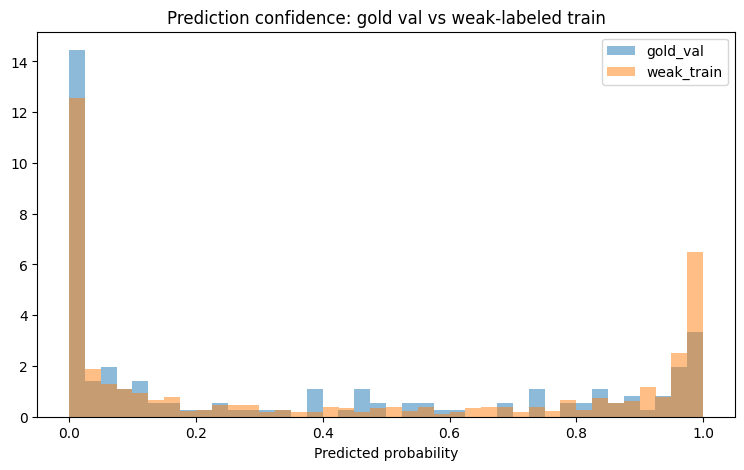

source
gold_val      0.777034
weak_train    0.811243
Name: mean_extremeness, dtype: float32


In [62]:
fig, ax = plt.subplots(figsize=(9, 5))
for source, color in [("gold_val", "C0"), ("weak_train", "C1")]:
    subset = all_preds[all_preds.source == source]["prob"]
    ax.hist(subset, bins=40, alpha=0.5, label=source, density=True, color=color)
ax.set_xlabel("Predicted probability")
ax.set_title("Prediction confidence: gold val vs weak-labeled train")
ax.legend()
plt.show()

print(all_preds.groupby("source")["prob"].apply(lambda x: np.mean(np.abs(x - 0.5) * 2)).rename("mean_extremeness"))

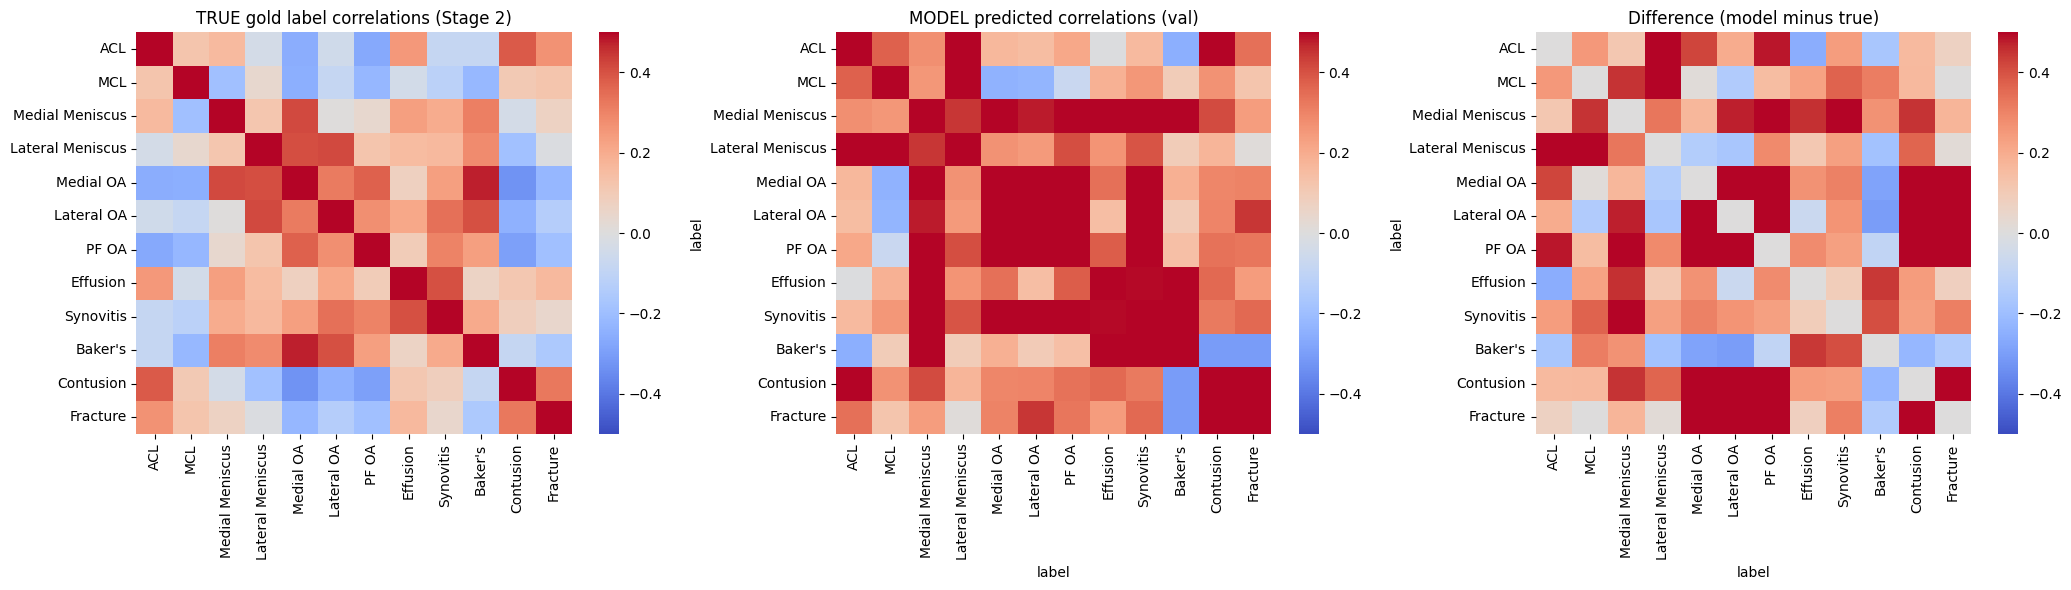

Mean |correlation|: true=0.197, predicted=0.366


In [63]:
gold_val_wide = gold_val_preds.pivot(index="study_id", columns="label", values="prob")[CFG.LABEL_COLS]
pred_corr = gold_val_wide.corr()

gold_true_corr = train_df.loc[label_present_mask, CFG.LABEL_COLS].corr()  # from Stage 2

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
sns.heatmap(gold_true_corr, ax=axes[0], cmap="coolwarm", center=0, vmin=-0.5, vmax=0.5, annot=False)
axes[0].set_title("TRUE gold label correlations (Stage 2)")
sns.heatmap(pred_corr, ax=axes[1], cmap="coolwarm", center=0, vmin=-0.5, vmax=0.5, annot=False)
axes[1].set_title("MODEL predicted correlations (val)")
sns.heatmap(pred_corr - gold_true_corr, ax=axes[2], cmap="coolwarm", center=0, vmin=-0.5, vmax=0.5, annot=False)
axes[2].set_title("Difference (model minus true)")
plt.tight_layout()
plt.show()

print(f"Mean |correlation|: true={gold_true_corr.abs().values[np.triu_indices(12,1)].mean():.3f}, "
      f"predicted={pred_corr.abs().values[np.triu_indices(12,1)].mean():.3f}")

In [65]:
def visualize_study_slots(study_id, series_dir=CFG.TRAIN_SERIES_DIR, series_df=train_series_df):
    study_series = series_df[series_df.StudyInstanceUID == study_id]
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for i, (plane, seq) in enumerate(CFG.CANONICAL_SLOTS):
        ax = axes[i // 3, i % 3]
        match = study_series[(study_series.Anatomical_Plane == plane) & (study_series.Fluid_Sensitive == seq)]
        if match.empty:
            ax.set_title(f"{plane} / {'fs' if seq else 'std'}\n(MISSING)")
            ax.axis("off")
            continue
        series_id = match.iloc[0].SeriesInstanceUID
        dcm_files = sorted((series_dir / study_id / series_id).glob("*.dcm"))
        mid_slice = load_dicom_slice(dcm_files[len(dcm_files) // 2])
        ax.imshow(mid_slice, cmap="gray")
        ax.set_title(f"{plane} / {'fs' if seq else 'std'}\n{len(dcm_files)} slices")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

Worst 5 studies by mean absolute error across all 12 labels:
study_id
1.2.826.0.1.3680043.8.498.72853333220043794904856138561095171921    0.552135
1.2.826.0.1.3680043.8.498.30246079718471552972130572444383079911    0.483105
1.2.826.0.1.3680043.8.498.62465595376489211274225312453216559395    0.436883
1.2.826.0.1.3680043.8.498.54977581323931277817074741182670080450    0.417086
1.2.826.0.1.3680043.8.498.29764868091238287072166823522853419550    0.295800
dtype: float32

Worst study 1.2.826.0.1.3680043.8.498.72853333220043794904856138561095171921:
                  true   pred
label                        
ACL                0.0  0.036
MCL                1.0  0.001
Medial Meniscus    0.0  0.620
Lateral Meniscus   0.0  0.124
Medial OA          0.0  0.917
Lateral OA         0.0  0.331
PF OA              0.0  0.946
Effusion           0.0  0.844
Synovitis          0.0  0.804
Baker's            0.0  0.954
Contusion          0.0  0.050
Fracture           0.0  0.000


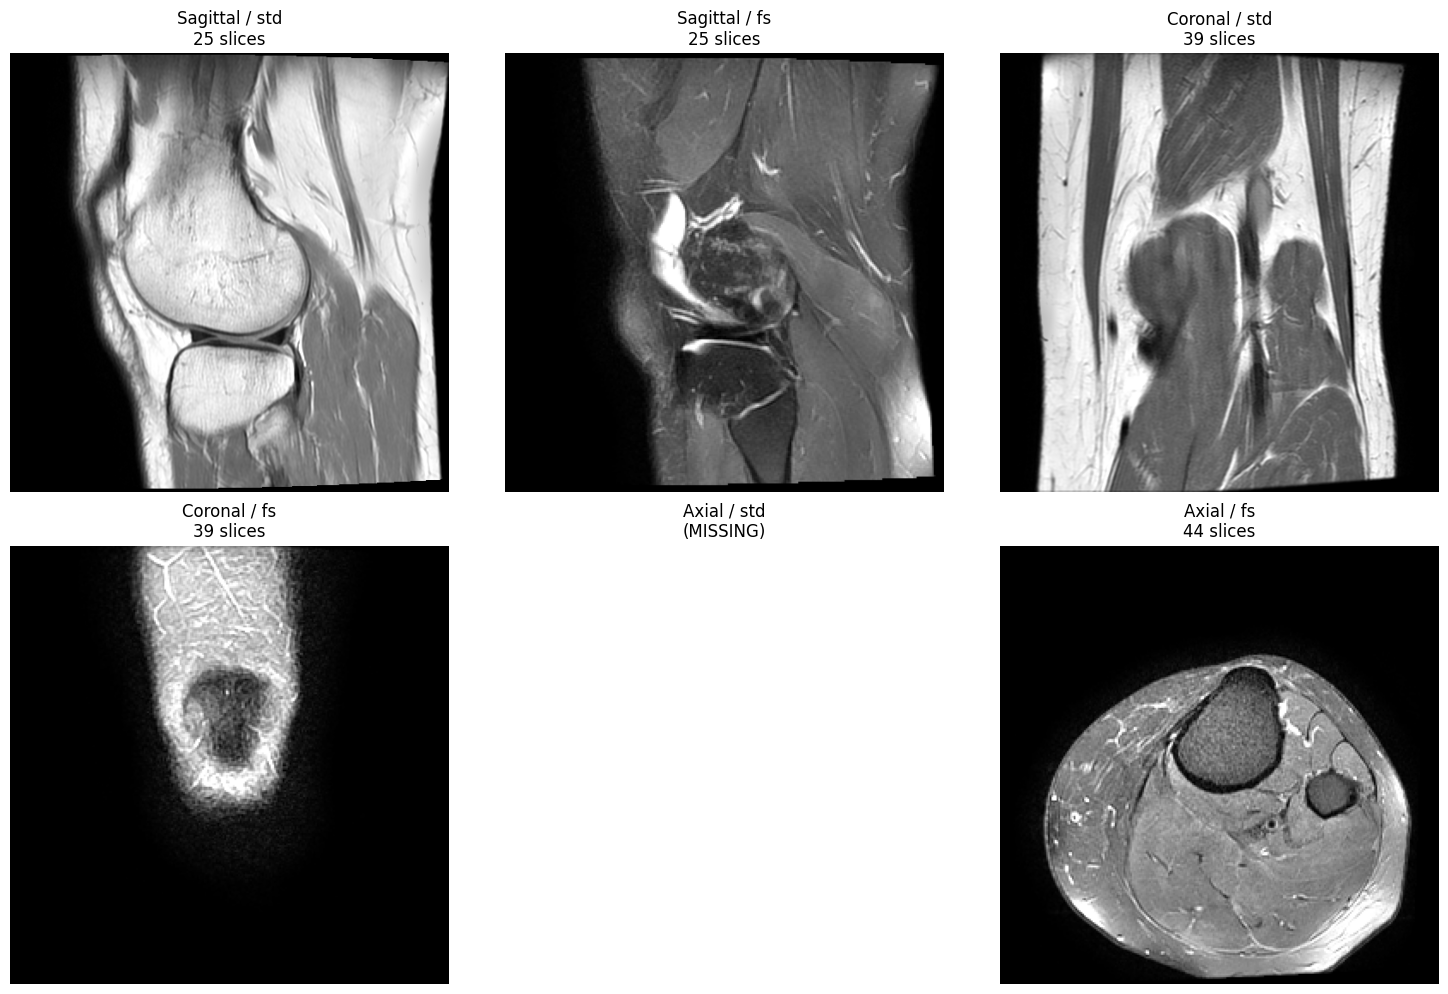

In [68]:
gold_val_wide_target = gold_val_preds.pivot(index="study_id", columns="label", values="target")[CFG.LABEL_COLS]
per_study_error = (gold_val_wide - gold_val_wide_target).abs().mean(axis=1).sort_values(ascending=False)
print("Worst 5 studies by mean absolute error across all 12 labels:")
print(per_study_error.head())

worst_study = per_study_error.index[0]
print(f"\nWorst study {worst_study}:")
comparison = pd.DataFrame({"true": gold_val_wide_target.loc[worst_study], "pred": gold_val_wide.loc[worst_study].round(3)})
print(comparison)
visualize_study_slots(worst_study)  # from Stage 2 — reuse to actually look at it

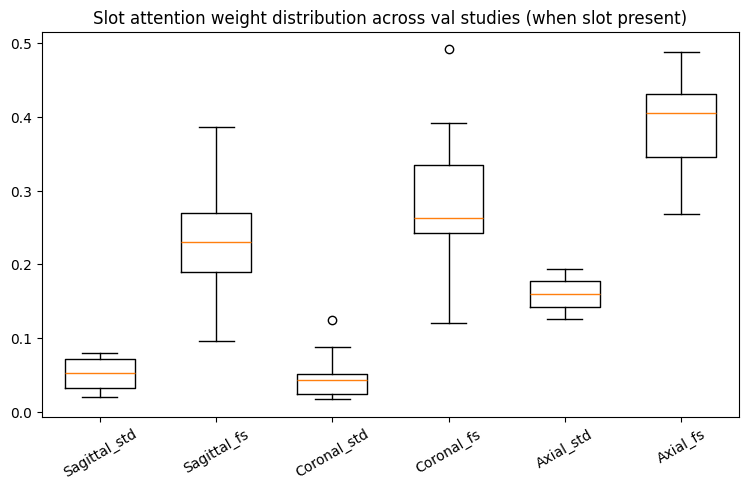

In [69]:
def collect_slot_attention(model, loader, device):
    model.eval()
    all_attn, all_mask = [], []
    with torch.no_grad():
        for batch in loader:
            images, slot_mask = batch["images"].to(device), batch["slot_mask"].to(device)
            with torch.cuda.amp.autocast(dtype=torch.float16):
                _, slot_attn = model(images, slot_mask)
            all_attn.append(slot_attn.float().cpu().numpy())
            all_mask.append(slot_mask.cpu().numpy())
    model.train()
    return np.concatenate(all_attn), np.concatenate(all_mask)

attn, mask = collect_slot_attention(model, val_loader, device)
fig, ax = plt.subplots(figsize=(9, 5))
for i, name in enumerate(CFG.SLOT_NAMES):
    valid_attn = attn[mask[:, i] == 1, i]
    ax.boxplot(valid_attn, positions=[i], widths=0.6)
ax.set_xticks(range(6)); ax.set_xticklabels(CFG.SLOT_NAMES, rotation=30)
ax.set_title("Slot attention weight distribution across val studies (when slot present)")
plt.show()

In [70]:
def per_label_confusion(all_preds, source="gold_val"):
    rows = []
    for lbl in CFG.LABEL_COLS:
        sub = all_preds[(all_preds.label == lbl) & (all_preds.source == source) & (all_preds.supervised == 1)]
        pred_class = (sub.prob >= 0.5).astype(int)
        tp = ((sub.target == 1) & (pred_class == 1)).sum()
        fp = ((sub.target == 0) & (pred_class == 1)).sum()
        fn = ((sub.target == 1) & (pred_class == 0)).sum()
        tn = ((sub.target == 0) & (pred_class == 0)).sum()
        rows.append({"label": lbl, "TP": tp, "FP": fp, "FN": fn, "TN": tn, "n": len(sub)})
    return pd.DataFrame(rows)

print(per_label_confusion(all_preds))

               label  TP  FP  FN  TN   n
0                ACL   0   0   4   8  12
1                MCL   1   0   1  10  12
2    Medial Meniscus   4   4   1   3  12
3   Lateral Meniscus   0   1   4   7  12
4          Medial OA   2   4   1   5  12
5         Lateral OA   1   3   1   7  12
6              PF OA   3   3   1   5  12
7           Effusion   5   3   0   4  12
8          Synovitis   4   3   2   3  12
9            Baker's   3   2   0   7  12
10         Contusion   1   1   2   8  12
11          Fracture   0   0   3   9  12
